In [1]:
import camelot
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import t

#### Aqui vamos a convertir las tablas de pdf a csv

In [ ]:
os.makedirs("./tables", exist_ok=True)

tables = camelot.read_pdf(
    "./Anexo.pdf",
    pages="453-481",
    flavor="lattice"
)

children_data = pd.concat([t.df for t in tables], ignore_index=True)
children_data.to_csv("./tables/children.csv", index=False)

### EDA básico

In [2]:
children = pd.read_csv("./tables/children.csv")
children = children.iloc[: , 4: ]
children = children[~(children == -2).all(axis = 1)]
children = children.dropna(axis=1, how="all")

adults = pd.read_excel("adults.xlsx")
adults = adults.iloc[:, 5:]
adults = adults.dropna(axis=1, how="all")

In [ ]:
children

In [ ]:
adults

In [ ]:
print("Datos de OPA en niños")
print(children.describe())
print(children.isnull().sum())


print("Datos de OPA en adultos")
print(adults.describe())
print(adults.isnull().sum())

### Distribución de los datos en escala original

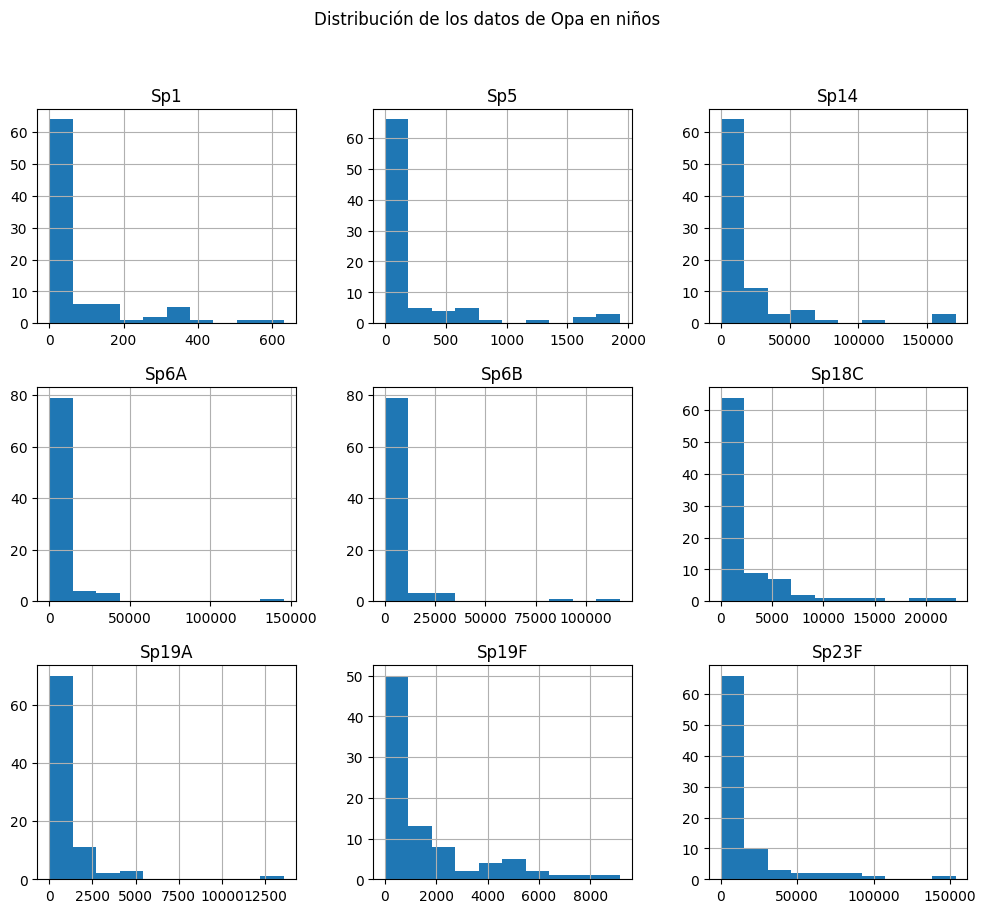

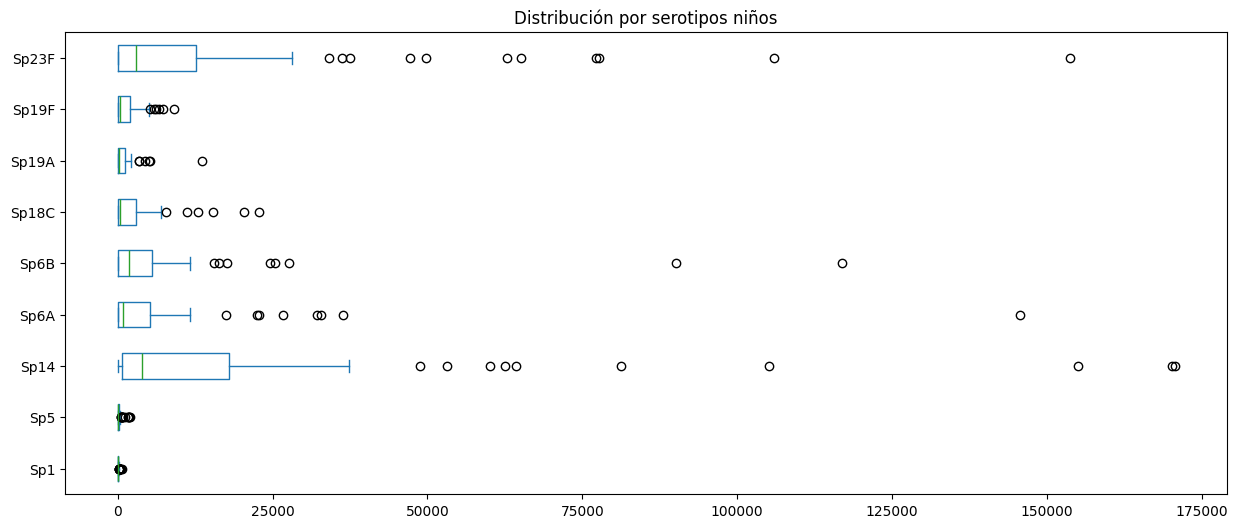

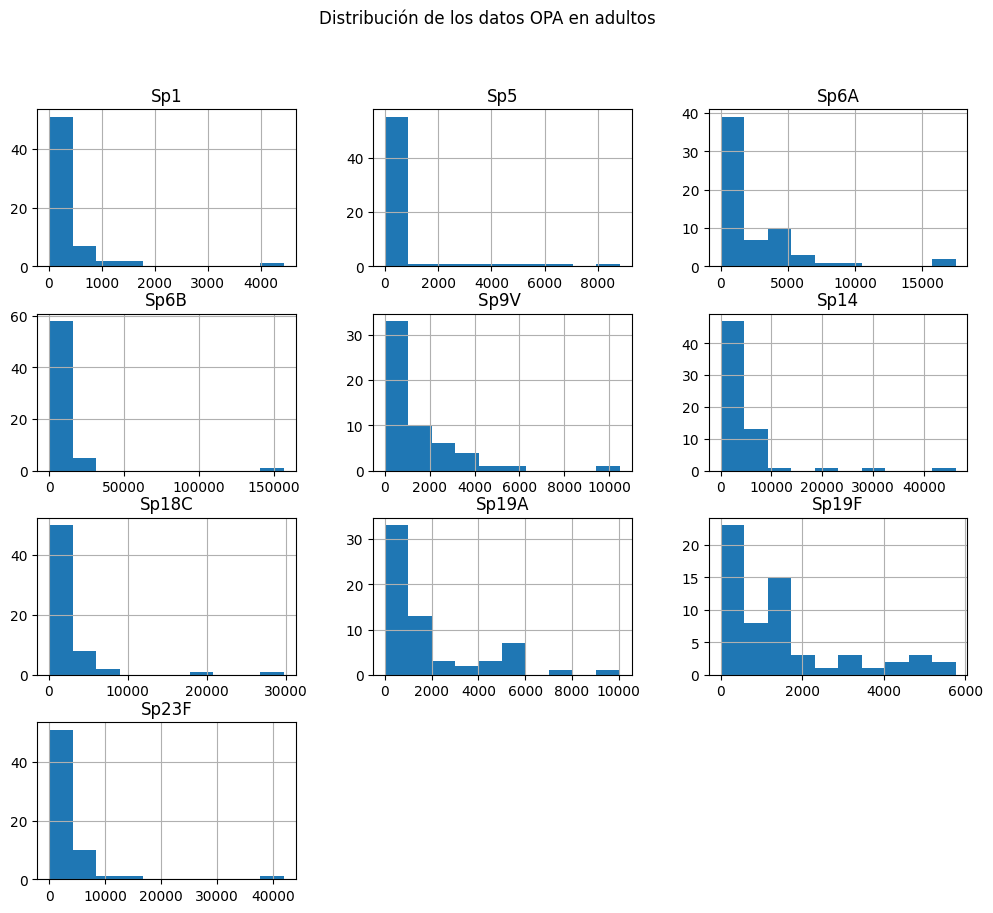

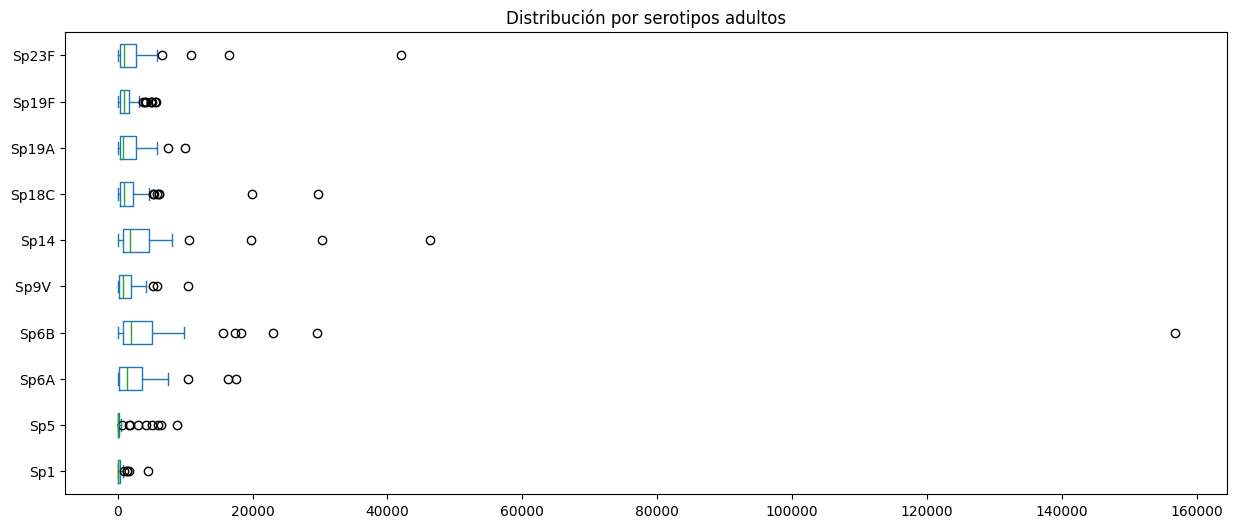

In [4]:
children.hist(figsize=(12, 10))
plt.suptitle("Distribución de los datos de Opa en niños")
plt.show()

children.plot(kind= "box", figsize=(15, 6), vert = False)  
plt.title('Distribución por serotipos niños')
plt.show()

adults.hist(figsize=(12, 10))
plt.suptitle("Distribución de los datos OPA en adultos")
plt.show
adults.plot(kind= "box", figsize=(15, 6), vert = False)  
plt.title('Distribución por serotipos adultos')
plt.show()


### Transformación a escala logarítmica

In [ ]:
columns = children.columns
print(columns)
#children = children.replace( 4, np.nan)
children = children.replace( -1, np.nan)
children[columns] = np.log(children[columns])
print(children.describe())

children

In [ ]:
columns = adults.columns
#adults = adults.replace( 4, np.nan)
adults = adults.replace( -1, np.nan)
adults[columns] = np.log(adults[columns])
print(adults.describe())
adults

### Nivel de censura en los resultados del ECA en ambos grupos y datos en escala logarítmica

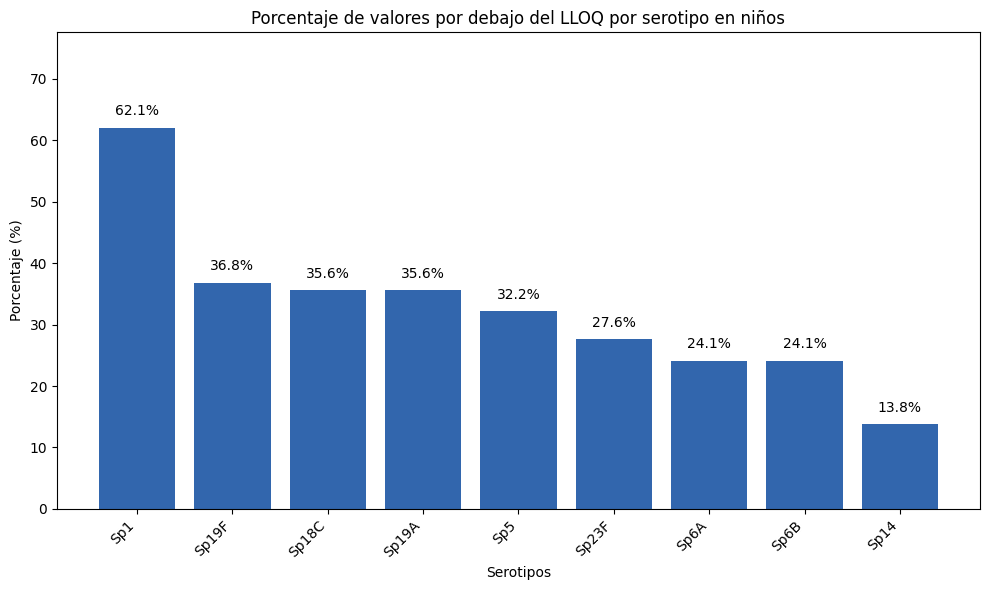

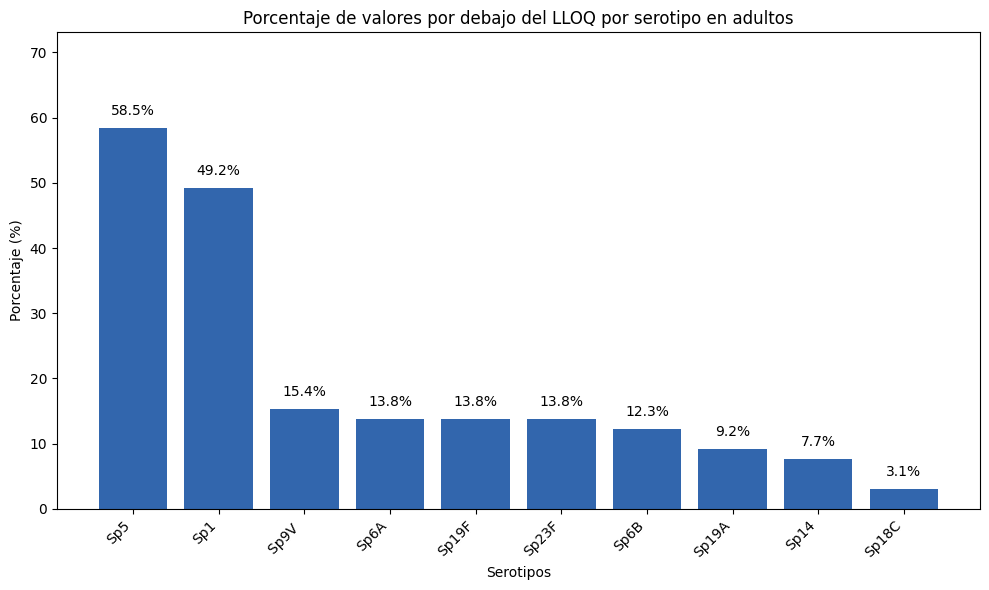

In [8]:
def visualize_lloq_pct(df, title):
    pct = (df <= np.log(4)).sum() / len(df) * 100
    pct = pct.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(pct.index, pct.values, color='#3266ad')

    ymax = max(pct.max() * 1.25, 10)
    for i, val in enumerate(pct.values):
        ax.text(i, val + ymax * 0.02, f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

    ax.set_xlabel('Serotipos')
    ax.set_ylabel('Porcentaje (%)')
    ax.set_title(title)
    ax.set_ylim(0, ymax)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

visualize_lloq_pct(children, 'Porcentaje de valores por debajo del LLOQ por serotipo en niños')
visualize_lloq_pct(adults, 'Porcentaje de valores por debajo del LLOQ por serotipo en adultos')
    

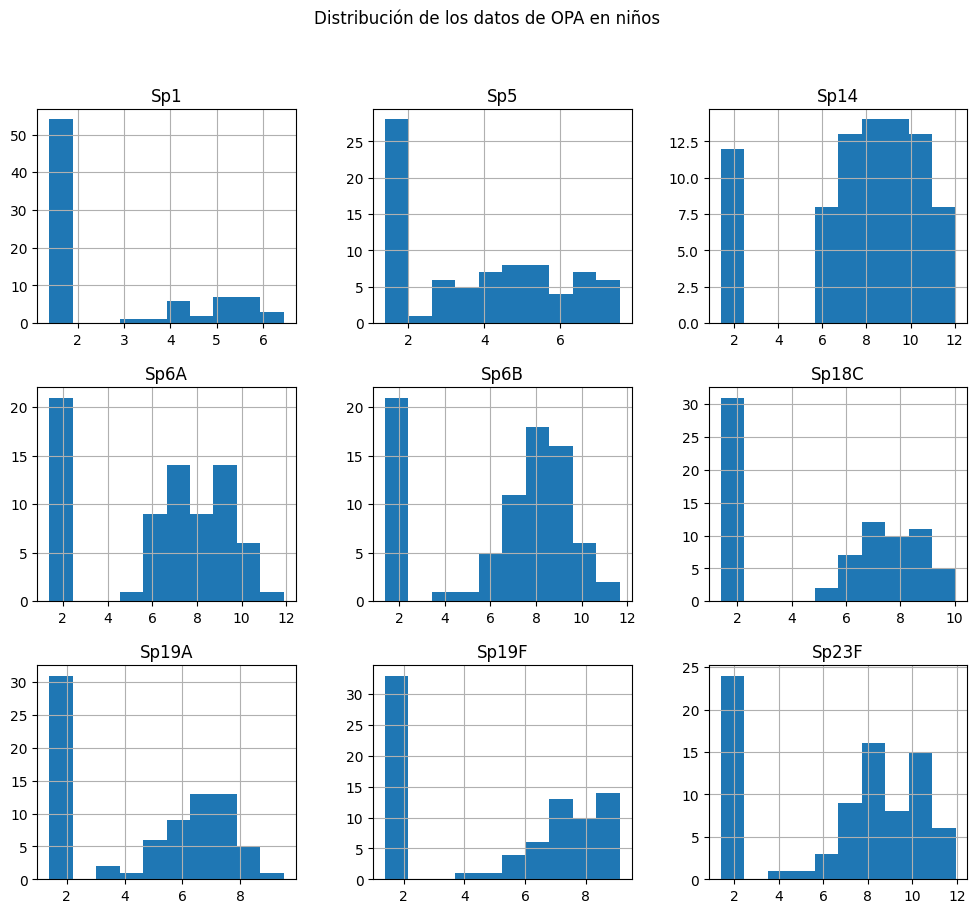

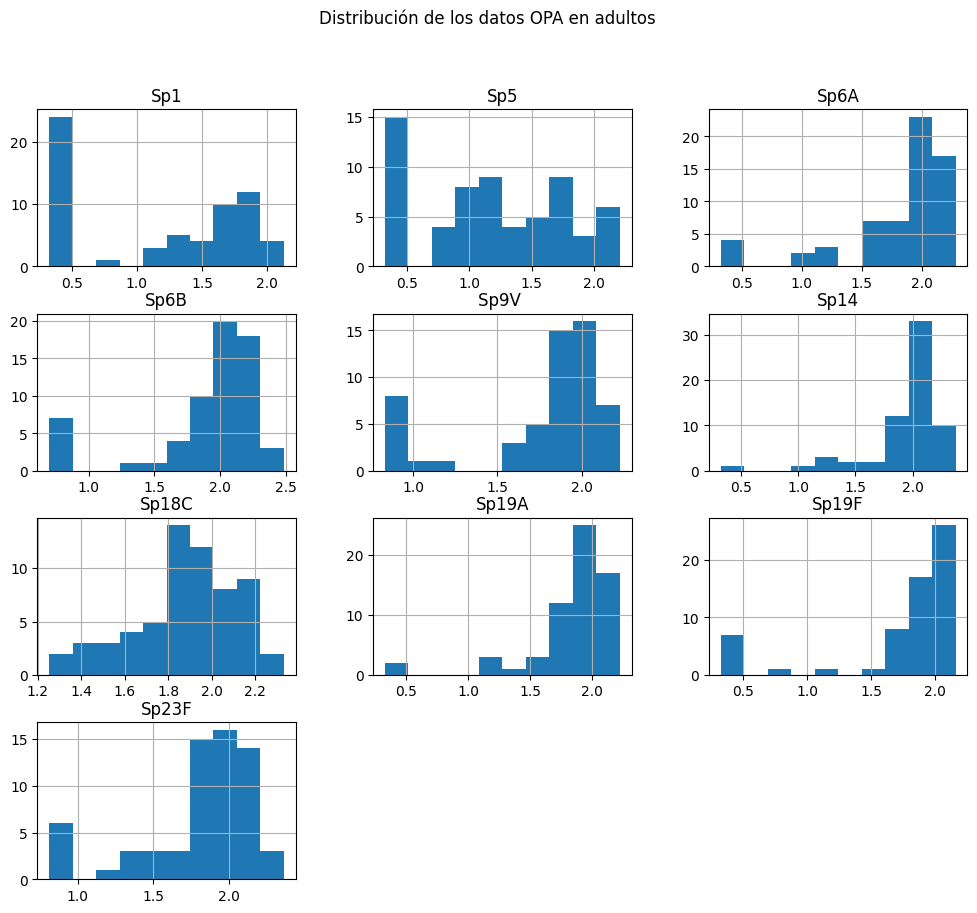

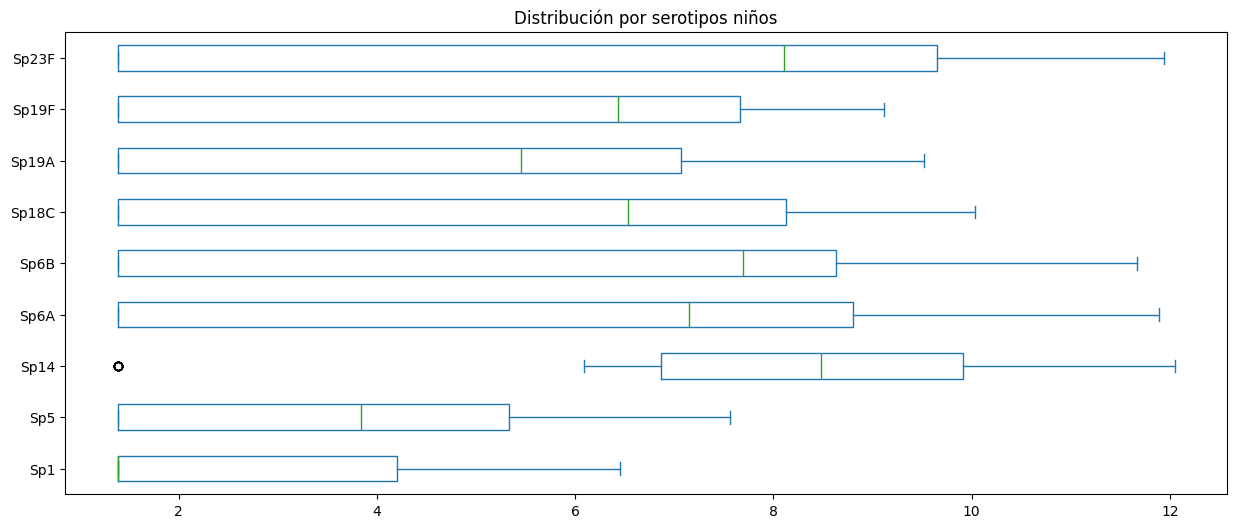

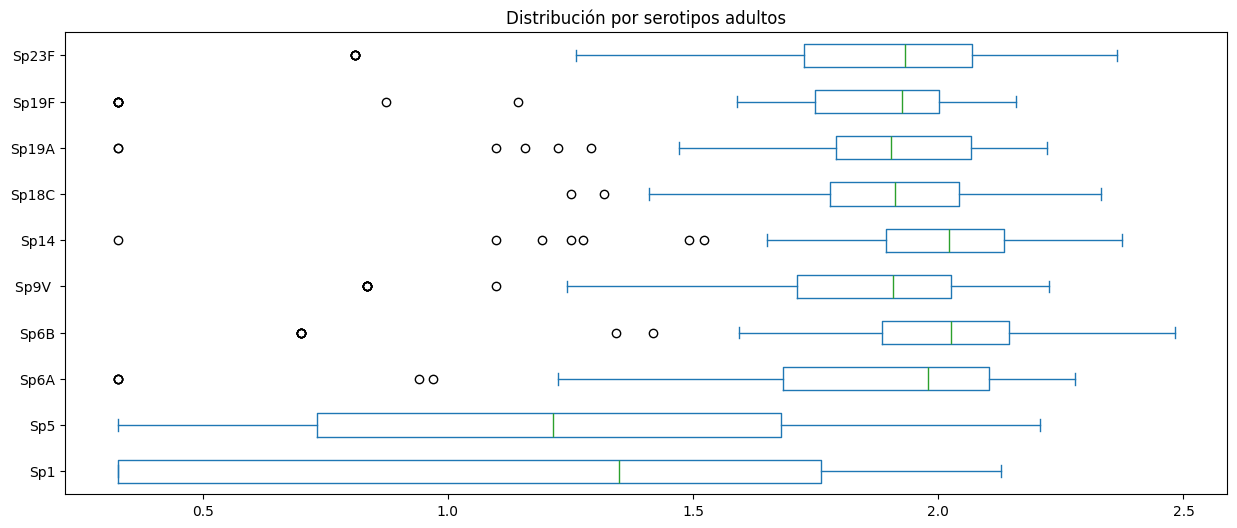

In [9]:
children.hist(figsize=(12, 10))
plt.suptitle("Distribución de los datos de OPA en niños")
plt.show()
adults.hist(figsize=(12, 10))
plt.suptitle("Distribución de los datos OPA en adultos")
plt.show

children.plot(kind= "box", figsize=(15, 6), vert = False)  
plt.title('Distribución por serotipos niños')
plt.show()

adults.plot(kind= "box", figsize=(15, 6), vert = False)  
plt.title('Distribución por serotipos adultos')
plt.show()

### Comprobando homocedasticidad entre los grupos

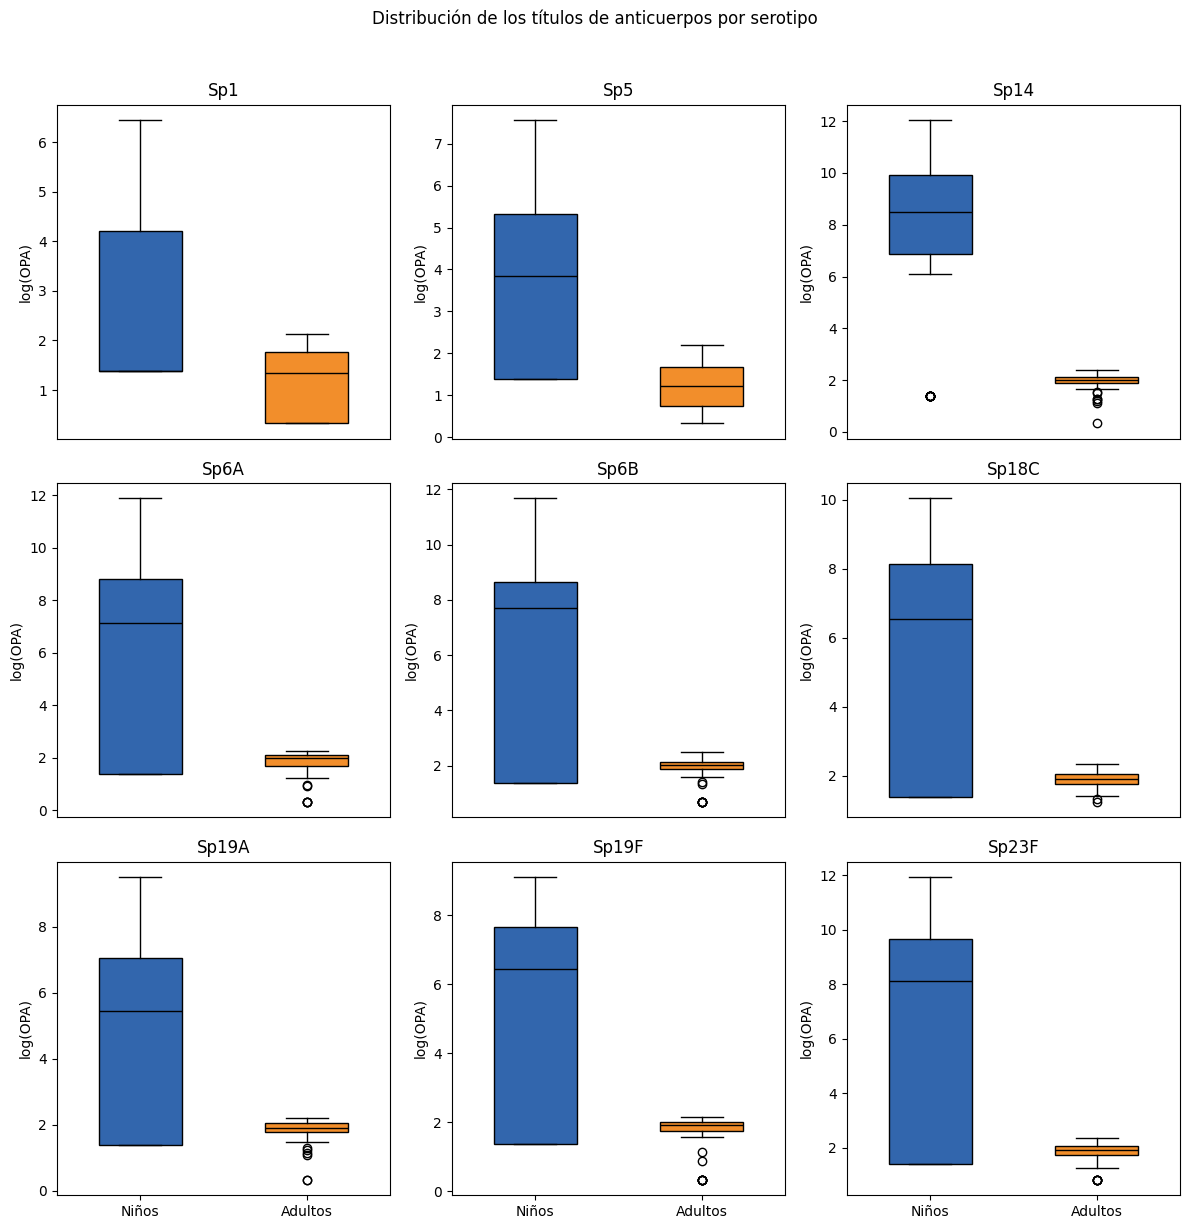

In [10]:
common_serotypes = [serotype for serotype in children.columns]
n = len(common_serotypes)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, (ax, serotype) in enumerate(zip(axes, common_serotypes)):
    data = [children[serotype].dropna(), adults[serotype].dropna()]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black'))
    bp['boxes'][0].set_facecolor('#3266ad')
    bp['boxes'][1].set_facecolor('#f28e2b')
    ax.set_title(serotype)
    ax.set_ylabel('log(OPA)')

    fila_actual = i // ncols
    if fila_actual < nrows - 1:
        ax.set_xticklabels([])        
        ax.tick_params(axis='x', length=0) 
    else:
        ax.set_xticklabels(['Niños', 'Adultos'])


for ax in axes[n:]:
    ax.set_visible(False)
fig.suptitle("Distribución de los títulos de anticuerpos por serotipo", y=1.02)
plt.tight_layout()
plt.savefig("boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Test de varianzas de Levene

In [11]:
from scipy import stats

variance_results = []

for serotype in common_serotypes:
    children_sp_data = children[serotype].dropna()
    adults_sp_data = adults[serotype].dropna()
    
    stat, p_value = stats.levene(children_sp_data, adults_sp_data, center='median')
    if p_value < 0.05:
        conclusion = "Sí"
    else:
        conclusion = "No"
        
    variance_results.append({
        'Serotipo': serotype,
        'Homocedasticidad': round(stat, 4),
        'p-valor': round(p_value, 4),
        'Método Sugerido': conclusion
    })

variance_results_df = pd.DataFrame(variance_results)
print(variance_results_df)

  Serotipo  Homocedasticidad  p-valor Método Sugerido
0      Sp1            7.0187    0.009              Sí
1      Sp5          112.4090    0.000              Sí
2     Sp14           52.2186    0.000              Sí
3     Sp6A           71.4236    0.000              Sí
4     Sp6B           51.4697    0.000              Sí
5    Sp18C          106.2721    0.000              Sí
6    Sp19A          128.9004    0.000              Sí
7    Sp19F           94.6033    0.000              Sí
8    Sp23F           69.1820    0.000              Sí


### Test de normalidad de los datos en escala logarítmica

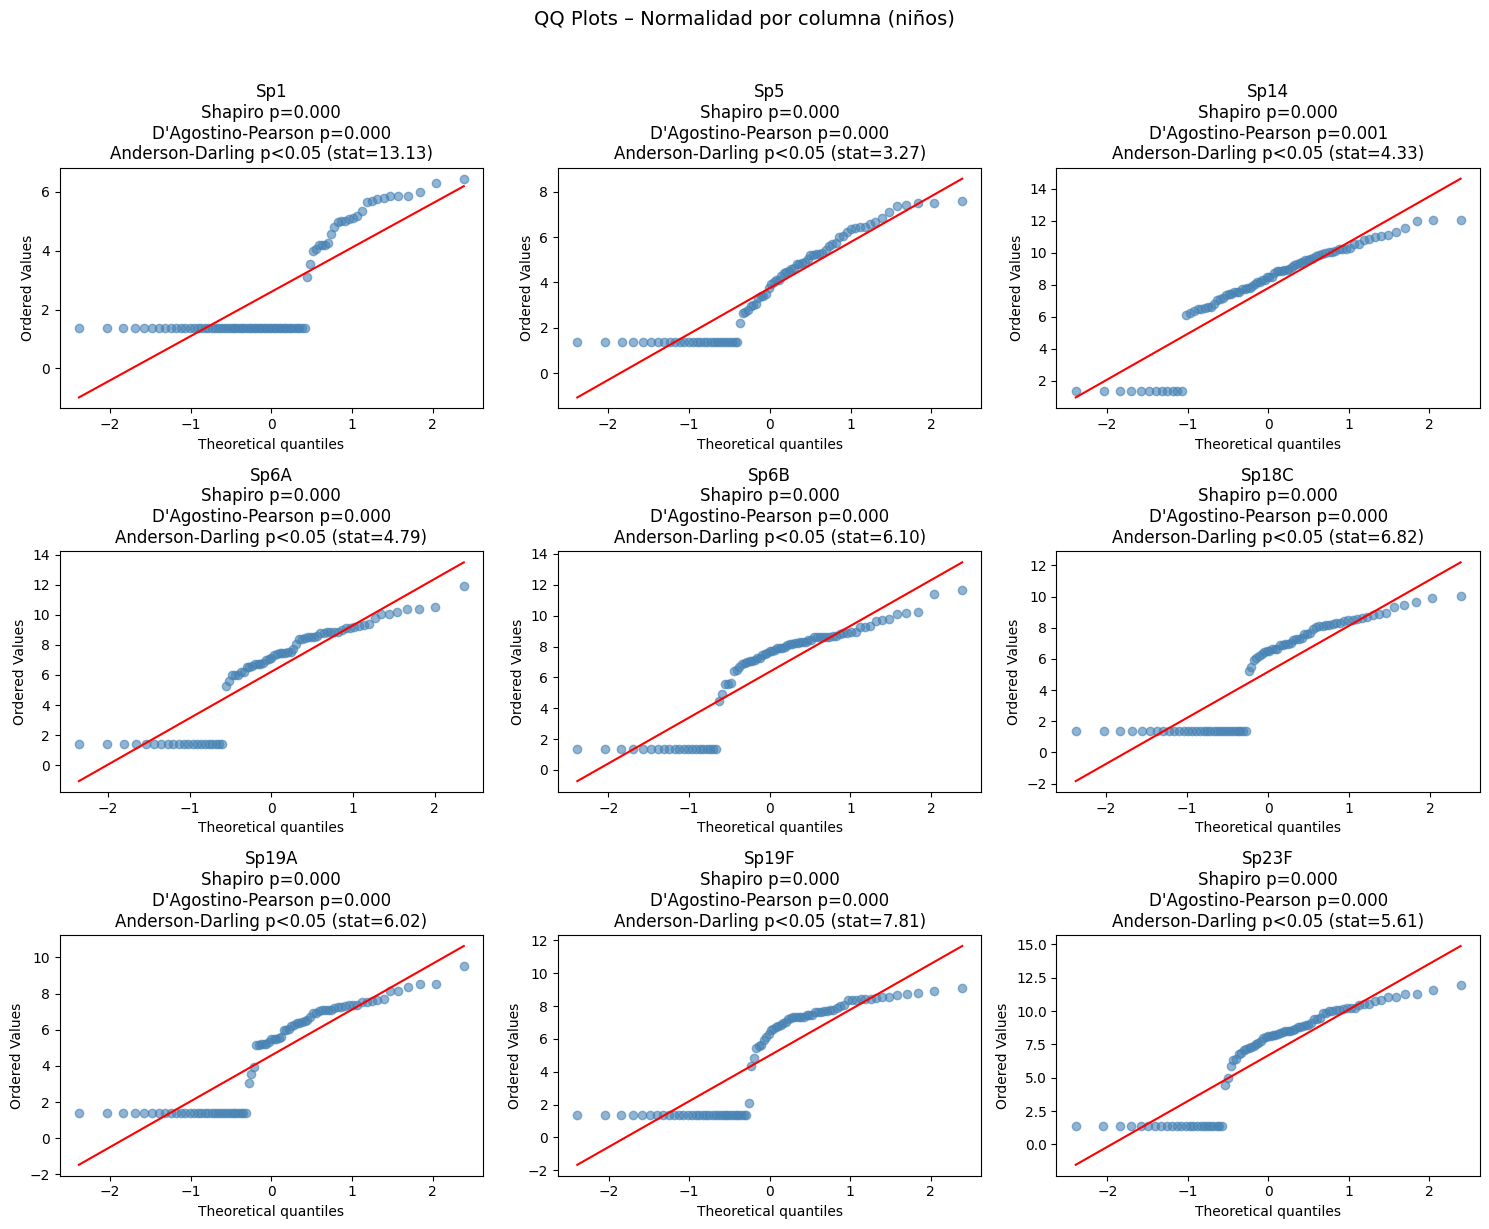

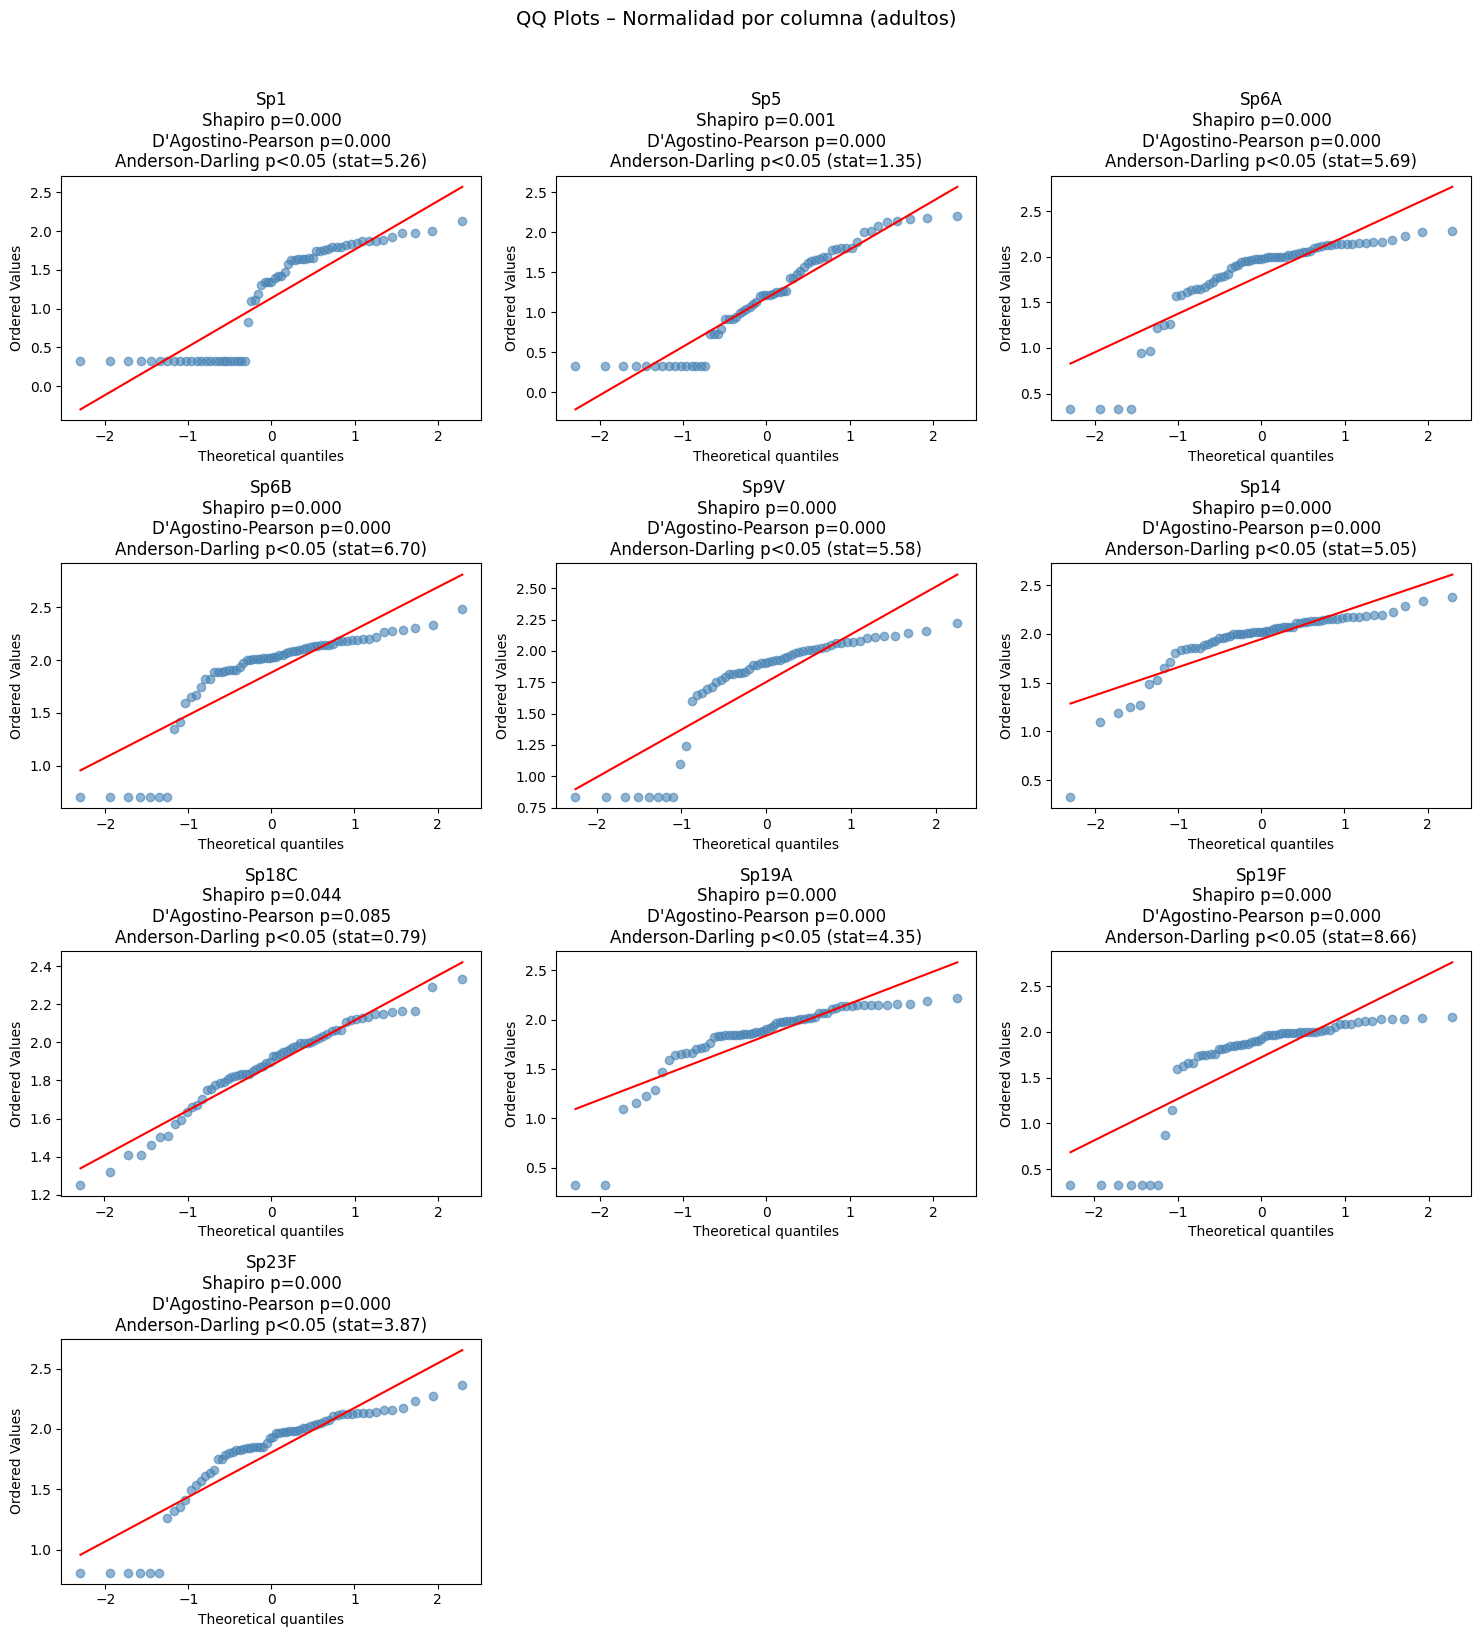

In [12]:
def plot_qq_grid(df, title):
    numeric_cols = df.select_dtypes(include='number').columns
    n_rows = int(np.ceil(len(numeric_cols) / 3))
    fig, axes = plt.subplots(n_rows, 3, figsize=(5 * 3, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        data = df[col].dropna()
        stats.probplot(data, dist="norm", plot=axes[i])
        axes[i].get_lines()[0].set(color='steelblue', alpha=0.6)
        axes[i].get_lines()[1].set(color='red')

        shapiro_stat, shapiro_p = stats.shapiro(data)
        ad_result = stats.anderson(data, dist='norm')
        ad_stat = ad_result.statistic
        ad_cv_5 = ad_result.critical_values[2]
        ad_p = "p<0.05" if ad_stat > ad_cv_5 else "p>=0.05"
        dagostino_stat, dagostino_p = stats.normaltest(data)

        axes[i].set_title(
            f'{col}\nShapiro p={shapiro_p:.3f}\n'
            f'D\'Agostino-Pearson p={dagostino_p:.3f}\n'
            f'Anderson-Darling {ad_p} (stat={ad_stat:.2f})'
        )

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_qq_grid(children, 'QQ Plots – Normalidad por columna (niños)')
plot_qq_grid(adults, 'QQ Plots – Normalidad por columna (adultos)')

### Curvas RCDC exploratorias

In [ ]:
children["Grupo"] = "Niños"
adults["Grupo"] = "Adultos"

df_total = pd.concat([children, adults], ignore_index=True)
df_long = pd.melt(
    df_total,
    id_vars=["Grupo"],
    value_vars=common_serotypes,
    var_name="Serotipo",
    value_name="Título OPA (Log)",
)

sns.set_theme(style="whitegrid", context="talk")

g = sns.FacetGrid(
    df_long,
    col="Serotipo",
    col_wrap=3,
    hue="Grupo",
    palette={"Niños": "#1f77b4", "Adultos": "#ff7f0e"},
    height=4.5,
    aspect=1.2,
    sharex=False,
)

g.map_dataframe(
    sns.ecdfplot,
    x="Título OPA (Log)",
    complementary=True,
    linewidth=2.5,
)

for ax in g.axes.flat:
    ax.set_ylim(-0.02, 1.02)
    ax.set_yticks([0.0, 0.25, 0.50, 0.75, 1.0])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])

    current_title = ax.get_title().split(" = ")[-1]
    ax.set_title(f"{current_title}", fontweight="bold", fontsize=14)

g.set_axis_labels("Título OPA (Log)", "Sujetos con título ≥ X")
g.add_legend(title="Población", adjust_subtitles=True)

plt.tight_layout()
plt.savefig("rcdc_results.png", dpi=300, bbox_inches="tight")
plt.show()


### Cálculo de GMT y GMR por sustitución

In [ ]:
n_child = len(children)
n_adult = len(adults)
results = []

for serotype in common_serotypes:

    children_data = children[serotype].dropna()
    adults_data = adults[serotype].dropna()

    mean_children, mean_adults = np.mean(children_data), np.mean(adults_data)
    gmt_children, gmt_adults = np.exp(mean_children), np.exp(mean_adults)
    delta = mean_adults - mean_children
    
    gmr = np.exp(delta)

    var_children = np.var(children_data, ddof=1)
    var_adults = np.var(adults_data, ddof=1)

    se_child = np.sqrt(var_children / len(children_data))
    t_crit_child = t.ppf(0.975, df=n_child - 1)
    
    gmt_lower_child = np.exp(mean_children - t_crit_child * se_child)
    gmt_upper_child = np.exp(mean_children + t_crit_child * se_child)
    se_adult = np.sqrt(var_adults / n_adult)
    t_crit_adult = t.ppf(0.975, df=n_adult - 1)
    
    gmt_lower_adult = np.exp(mean_adults - t_crit_adult * se_adult)
    gmt_upper_adult = np.exp(mean_adults + t_crit_adult * se_adult)
    
    se = np.sqrt( var_children / len(children_data) + var_adults / len(adults_data) )

    numer = (var_children/len(children_data) + var_adults/len(adults_data))**2
    denom = (var_children/len(children_data))**2/(len(children_data)-1) + (var_adults/len(adults_data))**2/(len(adults_data) - 1)
    df_welch = numer / denom
    t_crit = t.ppf(0.975, df_welch)

    lower_log = delta - t_crit * se
    upper_log = delta + t_crit * se
    lower = np.exp(lower_log)
    upper = np.exp(upper_log)

    non_inferior = lower > 0.5
    results.append({
        "Serotype": serotype,
        "GMT_Children": gmt_children,
        "GMT_Child_Lower": gmt_lower_child,
        "GMT_Child_Upper": gmt_upper_child,
        "GMT_Adults": gmt_adults,
        "GMT_Adult_Lower": gmt_lower_adult,
        "GMT_Adult_Upper": gmt_upper_adult,
        "GMR": gmr,
        "CI95_Lower": lower,
        "CI95_Upper": upper,
        "Non_Inferior": non_inferior
    })

results_df = pd.DataFrame(results)
results_df

### Comparación de GMTs por grupo etario con Sustitución Simple 

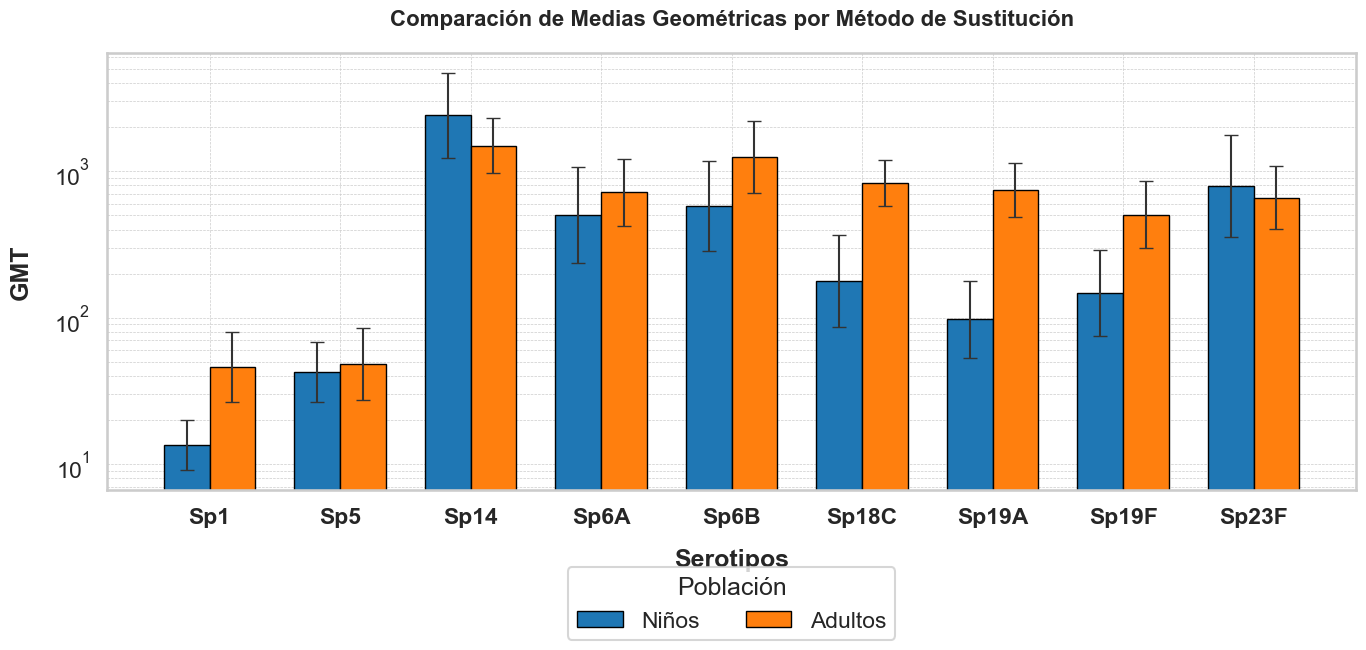

In [62]:
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(results_df["Serotype"]))
width = 0.35

yerr_children = [
    results_df["GMT_Children"] - results_df["GMT_Child_Lower"],
    results_df["GMT_Child_Upper"] - results_df["GMT_Children"],
]
yerr_adults = [
    results_df["GMT_Adults"] - results_df["GMT_Adult_Lower"],
    results_df["GMT_Adult_Upper"] - results_df["GMT_Adults"],
]

ax.bar(
    x - width / 2,
    results_df["GMT_Children"],
    width,
    yerr=yerr_children,
    color="#1f77b4",
    edgecolor="black",
    linewidth=1,
    error_kw={"capsize": 5, "linewidth": 1.5, "ecolor": "#333333"},
    label="Niños",
)

ax.bar(
    x + width / 2,
    results_df["GMT_Adults"],
    width,
    yerr=yerr_adults,
    color="#ff7f0e",
    edgecolor="black",
    linewidth=1,
    error_kw={"capsize": 5, "linewidth": 1.5, "ecolor": "#333333"},
    label="Adultos",
)

ax.set_yscale("log")
ax.set_title(
    "Comparación de Medias Geométricas por Método de Sustitución",
    fontweight="bold",
    fontsize=16,
    pad=20,
)
ax.set_xlabel("Serotipos", fontweight="bold", labelpad=15)
ax.set_ylabel(
    "GMT", fontweight="bold", labelpad=15
)

ax.set_xticks(x)
ax.set_xticklabels(results_df["Serotype"], fontweight="bold")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

ax.legend(
    title="Población",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=True,
)

plt.tight_layout()
plt.savefig("gmts.png", dpi=300, bbox_inches="tight")
plt.show()

In [147]:
children.to_csv("children_data.csv", index=False)
adults.to_csv("adults_data.csv", index=False)

In [ ]:
results_df = pd.DataFrame(results)
results_df

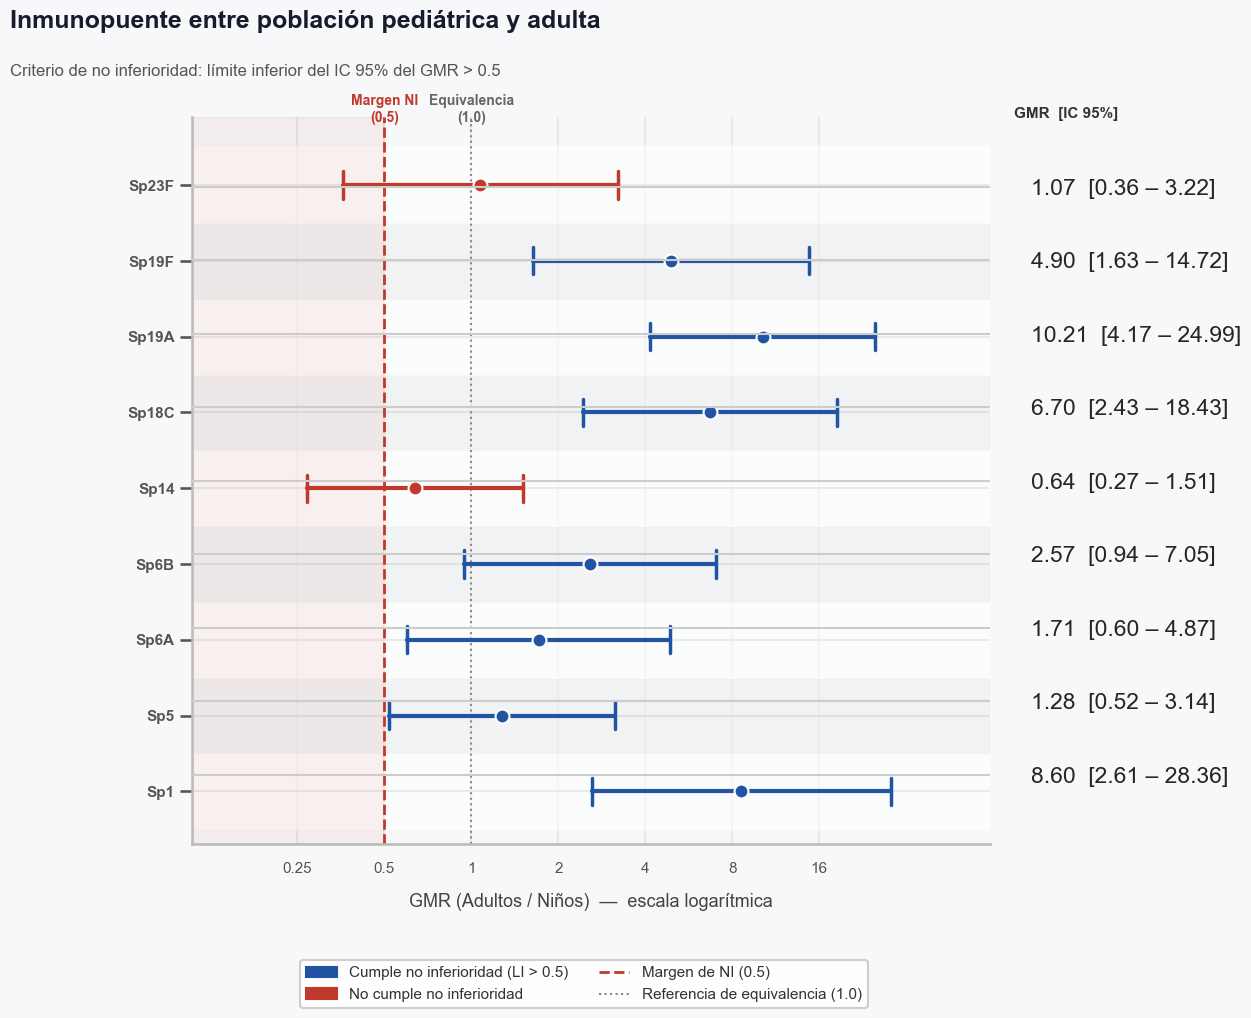

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np


plt.rcParams.update({'font.family': 'sans-serif',
                     'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans']})
COLOR_NI    = '#2155A3'
COLOR_NO_NI = '#C0392B'
fig, ax = plt.subplots(figsize=(14, len(results_df) * 0.8 + 3.5))
fig.patch.set_facecolor('#F7F8FA')
ax.set_facecolor('#F7F8FA')
fig.subplots_adjust(top=0.86, bottom=0.18, left=0.15, right=0.72)
fig.text(0.02, 0.96,
         'Inmunopuente entre población pediátrica y adulta',
         fontsize=18, fontweight='bold', color='#1A1A2E', va='top')
fig.text(0.02, 0.91,
         'Criterio de no inferioridad: límite inferior del IC 95% del GMR > 0.5',
         fontsize=12, color='#555555', va='top')

y = np.arange(len(results_df))
for i in range(len(results_df)):
    ax.axhspan(i - 0.5, i + 0.5,
               color='white' if i % 2 == 0 else '#EEEFF1',
               alpha=0.6, zorder=1)

x_min = results_df['CI95_Lower'].min() * 0.4
ax.axvspan(x_min, 0.5, color=COLOR_NO_NI, alpha=0.06, zorder=1)
ax.axvline(0.5, color=COLOR_NO_NI, linestyle='--', linewidth=2.0, zorder=2)
ax.axvline(1.0, color='#888888',   linestyle=':',  linewidth=1.5, zorder=2)
ax.text(0.5, len(results_df) - 0.2,
        'Margen NI\n(0.5)', va='bottom', ha='center',
        fontsize=10, color=COLOR_NO_NI, fontweight='bold')
ax.text(1.0, len(results_df) - 0.2,
        'Equivalencia\n(1.0)', va='bottom', ha='center',
        fontsize=10, color='#666666', fontweight='bold')

labels_list = []
for i, row in results_df.iterrows():
    cumple_ni = row['CI95_Lower'] > 0.5
    color = COLOR_NI if cumple_ni else COLOR_NO_NI

    ax.plot([row['CI95_Lower'], row['CI95_Upper']], [i, i],
            color=color, linewidth=3.0, solid_capstyle='round', zorder=3)

    for x in [row['CI95_Lower'], row['CI95_Upper']]:
        ax.plot([x, x], [i - 0.18, i + 0.18],
                color=color, linewidth=2.5, zorder=3)

    ax.plot(row['GMR'], i, 'o', color=color, markersize=10,
            markeredgecolor='white', markeredgewidth=1.5, zorder=4)

    labels_list.append(f"{row['GMR']:.2f}  [{row['CI95_Lower']:.2f} – {row['CI95_Upper']:.2f}]")

ax_text = ax.twinx()
ax_text.set_ylim(ax.get_ylim())
ax_text.set_yticks(y)
ax_text.set_yticklabels(labels_list, fontsize=11, fontfamily='monospace', color='#222222')
ax_text.spines['right'].set_position(('axes', 1.03)) 
ax_text.spines[['top', 'left', 'bottom', 'right']].set_visible(False)
ax_text.tick_params(left=False, right=False)
ax_text.text(1.03, len(results_df) - 0.1, 'GMR  [IC 95%]',
             va='bottom', ha='left', transform=ax_text.get_yaxis_transform(),
             fontsize=11, fontweight='bold', color='#333333')

ax.set_xscale('log')
ticks = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax.set_xlim(x_min, results_df['CI95_Upper'].max() * 2.2)
ax.set_yticks(y)
ax.set_yticklabels(results_df['Serotype'],
                   fontsize=12, fontweight='bold', color='#1A1A2E')
ax.set_xlabel('GMR (Adultos / Niños)  —  escala logarítmica',
              fontsize=13, color='#444444', labelpad=12)
ax.set_ylim(-0.7, len(results_df) - 0.1)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#BBBBBB')
ax.tick_params(colors='#555555', labelsize=11)
ax.grid(axis='x', alpha=0.2, color='#AAAAAA', linestyle='-', zorder=0)

legend_elements = [
    mpatches.Patch(color=COLOR_NI,    label='Cumple no inferioridad (LI > 0.5)'),
    mpatches.Patch(color=COLOR_NO_NI, label='No cumple no inferioridad'),
    plt.Line2D([0], [0], color=COLOR_NO_NI, linestyle='--',
               linewidth=2.0, label='Margen de NI (0.5)'),
    plt.Line2D([0], [0], color='#888888', linestyle=':',
               linewidth=1.5, label='Referencia de equivalencia (1.0)'),
]
fig.legend(handles=legend_elements,
           loc='lower center',
           bbox_to_anchor=(0.43, 0.02),
           ncol=2, fontsize=11, 
           framealpha=0.95, edgecolor='#CCCCCC',
           labelcolor='#333333')

plt.savefig('forest_plot_ni_presentation.png', dpi=300,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### GMT y No inferioridad por MLE

In [18]:
# estos son los datos de R para comprobar el metodo en Python
results_mle = pd.read_csv("results_MLE.csv")
results_mle

,Serotype,N_Children,N_Adults,Cens_Children,Cens_Adults,GMT_Children,CI95_GMT_Ch,GMT_Adults,CI95_GMT_Ad,GMR,CI95_Lower,CI95_Upper,Non_Inferior
0,Sp1,81,63,54 (66.7%),24 (38.1%),2.16,"[0.6, 7.8]",29.28,"[13.37, 64.1]",8.60,2.61,28.37,True
1,Sp5,80,63,28 (35.0%),15 (23.8%),30.15,"[16.12, 56.37]",38.84,"[19.89, 75.84]",1.28,0.52,3.14,True
2,Sp6A,75,63,21 (28.0%),4 (6.3%),334.20,"[129.96, 859.47]",715.48,"[421.3, 1215.06]",1.71,0.60,4.87,True
3,Sp6B,81,64,21 (25.9%),0 (0.0%),418.76,"[177.19, 989.67]",1245.15,"[712.95, 2174.63]",2.57,0.94,7.05,True
4,Sp14,82,64,12 (14.6%),1 (1.6%),2194.62,"[1077.46, 4470.09]",1504.39,"[984.47, 2298.89]",0.64,0.27,1.51,False
5,Sp18C,78,62,31 (39.7%),0 (0.0%),74.10,"[24.31, 225.88]",831.14,"[576.17, 1198.93]",6.70,2.43,18.44,True
6,Sp19A,81,63,31 (38.3%),2 (3.2%),52.26,"[21.71, 125.83]",749.21,"[491.01, 1143.19]",10.21,4.17,24.99,True
7,Sp19F,82,61,32 (39.0%),7 (11.5%),67.36,"[24.39, 186]",498.97,"[289.23, 860.8]",4.90,1.63,14.72,True
8,Sp23F,83,64,24 (28.9%),0 (0.0%),472.34,"[168.73, 1322.26]",658.27,"[404.3, 1071.78]",1.07,0.36,3.22,False


In [22]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize

LLOQ = 8.0
THRESHOLD_LN = np.log(LLOQ)
HALF_LLOQ_LN = np.log(LLOQ / 2)

def compute_exact_hessian(f, x, h=1e-5):
    n = len(x)
    hess = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                x_plus = np.array(x, dtype=float)
                x_minus = np.array(x, dtype=float)
                x_plus[i] += h
                x_minus[i] -= h
                hess[i, i] = (f(x_plus) - 2 * f(x) + f(x_minus)) / (h ** 2)
            else:
                x_pp = np.array(x, dtype=float)
                x_pm = np.array(x, dtype=float)
                x_mp = np.array(x, dtype=float)
                x_mm = np.array(x, dtype=float)
                
                x_pp[i] += h; x_pp[j] += h
                x_pm[i] += h; x_pm[j] -= h
                x_mp[i] -= h; x_mp[j] += h
                x_mm[i] -= h; x_mm[j] -= h
                
                hess[i, j] = (f(x_pp) - f(x_pm) - f(x_mp) + f(x_mm)) / (4 * h ** 2)
    return hess

def fit_tobit_left_censored(X, y, is_censored, threshold):
    def neg_log_likelihood(params):
        beta = params[:-1]
        log_sigma = params[-1]
        sigma = np.exp(log_sigma) 
        
        mu = X @ beta
        z_obs = (y[~is_censored] - mu[~is_censored]) / sigma
        ll_obs = -log_sigma - 0.5 * np.log(2 * np.pi) - 0.5 * (z_obs ** 2)
        
        z_cens = (threshold - mu[is_censored]) / sigma
        ll_cens = norm.logcdf(z_cens)
        
        return -(np.sum(ll_obs) + np.sum(ll_cens))

    beta_init = np.linalg.lstsq(X, y, rcond=None)[0]
    sigma_init = np.std(y) if np.std(y) > 0 else 1.0
    log_sigma_init = np.log(sigma_init)
    init_params = np.append(beta_init, log_sigma_init)
    
    res = minimize(neg_log_likelihood, init_params, method='BFGS', options={'gtol': 1e-8})
    if not res.success:
        res = minimize(neg_log_likelihood, init_params, method='Nelder-Mead')
        res = minimize(neg_log_likelihood, res.x, method='BFGS', options={'gtol': 1e-8})

    opt_params = res.x
    beta_opt = opt_params[:-1]
    hessian = compute_exact_hessian(neg_log_likelihood, opt_params)
    
    try:
        vcov = np.linalg.inv(hessian)
        se_beta = np.sqrt(np.diag(vcov))[:-1]
    except np.linalg.LinAlgError:
        se_beta = np.full(len(beta_opt), np.nan)
        
    return beta_opt, se_beta

results = []

for serotype in common_serotypes:
    
    ch_raw = children[serotype].dropna().values
    ad_raw = adults[serotype].dropna().values
    
    n_ch = len(ch_raw)
    n_ad = len(ad_raw)
    
    cens_ch = np.isclose(ch_raw, HALF_LLOQ_LN)
    cens_ad = np.isclose(ad_raw, HALF_LLOQ_LN)
    
    n_cens_ch = np.sum(cens_ch)
    n_cens_ad = np.sum(cens_ad)
    
    ch_raw = np.where(cens_ch, THRESHOLD_LN, ch_raw)
    ad_raw = np.where(cens_ad, THRESHOLD_LN, ad_raw)
    
    X_ch = np.ones((n_ch, 1))
    X_ad = np.ones((n_ad, 1))
    
    beta_ch, se_ch = fit_tobit_left_censored(X_ch, ch_raw, cens_ch, THRESHOLD_LN)
    beta_ad, se_ad = fit_tobit_left_censored(X_ad, ad_raw, cens_ad, THRESHOLD_LN)
    
    mu_ch, se_mu_ch = beta_ch[0], se_ch[0]
    mu_ad, se_mu_ad = beta_ad[0], se_ad[0]
    
    gmt_ch = np.exp(mu_ch)
    gmt_ad = np.exp(mu_ad)
    
    ic_ch_lo = np.exp(mu_ch - 1.96 * se_mu_ch)
    ic_ch_hi = np.exp(mu_ch + 1.96 * se_mu_ch)
    ic_ad_lo = np.exp(mu_ad - 1.96 * se_mu_ad)
    ic_ad_hi = np.exp(mu_ad + 1.96 * se_mu_ad)
    
    y_joint = np.concatenate([ch_raw, ad_raw])
    cens_joint = np.concatenate([cens_ch, cens_ad])
    
    X_joint = np.column_stack([
        np.ones(n_ch + n_ad), 
        np.concatenate([np.zeros(n_ch), np.ones(n_ad)])
    ])
    
    beta_joint, se_joint = fit_tobit_left_censored(X_joint, y_joint, cens_joint, THRESHOLD_LN)
    delta = beta_joint[1]
    se_delta = se_joint[1] 
    
    gmr = np.exp(delta)
    lower = np.exp(delta - 1.96 * se_delta)
    upper = np.exp(delta + 1.96 * se_delta)
    
    non_inferior = lower > 0.5
    results.append({
        "Serotype": serotype,
        "N_Children": n_ch,
        "N_Adults": n_ad,
        "Cens_Children": f"{n_cens_ch} ({(n_cens_ch / n_ch) * 100:.1f}%)",
        "Cens_Adults": f"{n_cens_ad} ({(n_cens_ad / n_ad) * 100:.1f}%)",
        "GMT_Children": round(gmt_ch, 2),
        "CI95_GMT_Ch": f"[{round(ic_ch_lo, 2)}, {round(ic_ch_hi, 2)}]",
        "GMT_Adults": round(gmt_ad, 2),
        "CI95_GMT_Ad": f"[{round(ic_ad_lo, 2)}, {round(ic_ad_hi, 2)}]",
        "GMR": round(gmr, 2),
        "CI95_Lower": round(lower, 2),
        "CI95_Upper": round(upper, 2),
        "Non_Inferior": non_inferior
    })

results_df = pd.DataFrame(results)
print(results_df)

  Serotype  N_Children  N_Adults Cens_Children Cens_Adults  GMT_Children  \
0      Sp1          81        63    54 (66.7%)  24 (38.1%)          2.16   
1      Sp5          80        63    28 (35.0%)  15 (23.8%)         30.15   
2     Sp6A          75        63    21 (28.0%)    4 (6.3%)        334.20   
3     Sp6B          81        64    21 (25.9%)    0 (0.0%)        418.76   
4     Sp14          82        64    12 (14.6%)    1 (1.6%)       2194.62   
5    Sp18C          78        62    31 (39.7%)    0 (0.0%)         74.10   
6    Sp19A          81        63    31 (38.3%)    2 (3.2%)         52.26   
7    Sp19F          82        61    32 (39.0%)   7 (11.5%)         67.36   
8    Sp23F          83        64    24 (28.9%)    0 (0.0%)        472.34   

          CI95_GMT_Ch  GMT_Adults        CI95_GMT_Ad    GMR  CI95_Lower  \
0          [0.6, 7.8]       29.28     [13.37, 64.09]   8.60        2.61   
1      [16.12, 56.36]       38.84     [19.89, 75.84]   1.28        0.52   
2    [129.96, 

In [21]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize, root_scalar

LLOQ = 8.0
THRESHOLD_LN = np.log(LLOQ)
HALF_LLOQ_LN = np.log(LLOQ / 2)

def compute_exact_hessian(f, x, h=1e-5):
    n = len(x)
    hess = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                x_plus  = np.array(x, dtype=float); x_plus[i]  += h
                x_minus = np.array(x, dtype=float); x_minus[i] -= h
                hess[i, i] = (f(x_plus) - 2 * f(x) + f(x_minus)) / h**2
            else:
                x_pp = np.array(x, dtype=float); x_pp[i] += h; x_pp[j] += h
                x_pm = np.array(x, dtype=float); x_pm[i] += h; x_pm[j] -= h
                x_mp = np.array(x, dtype=float); x_mp[i] -= h; x_mp[j] += h
                x_mm = np.array(x, dtype=float); x_mm[i] -= h; x_mm[j] -= h
                hess[i, j] = (f(x_pp) - f(x_pm) - f(x_mp) + f(x_mm)) / (4 * h**2)
    return hess

def fit_tobit_left_censored(X, y, is_censored, threshold):

    def neg_log_likelihood(params):
        beta      = params[:-1]
        log_sigma = params[-1]
        sigma     = np.exp(log_sigma)
        mu        = X @ beta

        z_obs  = (y[~is_censored] - mu[~is_censored]) / sigma
        ll_obs = -log_sigma - 0.5 * np.log(2 * np.pi) - 0.5 * z_obs**2

        z_cens  = (threshold - mu[is_censored]) / sigma
        ll_cens = norm.logcdf(z_cens)

        return -(np.sum(ll_obs) + np.sum(ll_cens))

    beta_init      = np.linalg.lstsq(X, y, rcond=None)[0]
    sigma_init     = np.std(y) if np.std(y) > 0 else 1.0
    log_sigma_init = np.log(sigma_init)
    init_params    = np.append(beta_init, log_sigma_init)

    res = minimize(neg_log_likelihood, init_params, method='BFGS',
                   options={'gtol': 1e-8})
    if not res.success:
        res = minimize(neg_log_likelihood, init_params, method='Nelder-Mead')
        res = minimize(neg_log_likelihood, res.x, method='BFGS',
                       options={'gtol': 1e-8})

    opt_params = res.x
    beta_opt   = opt_params[:-1]
    nll_min    = res.fun   # <-- nuevo

    hessian = compute_exact_hessian(neg_log_likelihood, opt_params)
    try:
        vcov    = np.linalg.inv(hessian)
        se_beta = np.sqrt(np.diag(vcov))[:-1]
    except np.linalg.LinAlgError:
        se_beta = np.full(len(beta_opt), np.nan)

    return beta_opt, se_beta, nll_min, neg_log_likelihood, opt_params  # <-- nuevos


results = []

for serotype in common_serotypes:

    ch_raw = children[serotype].dropna().values
    ad_raw = adults[serotype].dropna().values

    n_ch = len(ch_raw)
    n_ad = len(ad_raw)

    cens_ch = np.isclose(ch_raw, HALF_LLOQ_LN)
    cens_ad = np.isclose(ad_raw, HALF_LLOQ_LN)

    n_cens_ch = np.sum(cens_ch)
    n_cens_ad = np.sum(cens_ad)

    ch_raw = np.where(cens_ch, THRESHOLD_LN, ch_raw)
    ad_raw = np.where(cens_ad, THRESHOLD_LN, ad_raw)

    X_ch = np.ones((n_ch, 1))
    X_ad = np.ones((n_ad, 1))


    beta_ch, se_ch, nll_min_ch, nll_func_ch, opt_params_ch = \
        fit_tobit_left_censored(X_ch, ch_raw, cens_ch, THRESHOLD_LN)

    beta_ad, se_ad, nll_min_ad, nll_func_ad, opt_params_ad = \
        fit_tobit_left_censored(X_ad, ad_raw, cens_ad, THRESHOLD_LN)

    mu_ch, se_mu_ch = beta_ch[0], se_ch[0]
    mu_ad, se_mu_ad = beta_ad[0], se_ad[0]

    gmt_ch = np.exp(mu_ch)
    gmt_ad = np.exp(mu_ad)

    wald_ch_lo = np.exp(mu_ch - 1.96 * se_mu_ch)
    wald_ch_hi = np.exp(mu_ch + 1.96 * se_mu_ch)
    wald_ad_lo = np.exp(mu_ad - 1.96 * se_mu_ad)
    wald_ad_hi = np.exp(mu_ad + 1.96 * se_mu_ad)

    def profiled_target_ch(mu_val):
        def nll_restricted(rp):
            return nll_func_ch(np.array([mu_val, rp[0]]))
        r = minimize(nll_restricted, [opt_params_ch[1]], method='BFGS',
                     options={'gtol': 1e-6})
        return (r.fun - nll_min_ch) - 1.9207

    try:
        prof_ch_lo = np.exp(root_scalar(profiled_target_ch,
                            bracket=[mu_ch - 4*se_mu_ch, mu_ch],
                            method='brentq').root)
    except ValueError:
        prof_ch_lo = wald_ch_lo

    try:
        prof_ch_hi = np.exp(root_scalar(profiled_target_ch,
                            bracket=[mu_ch, mu_ch + 4*se_mu_ch],
                            method='brentq').root)
    except ValueError:
        prof_ch_hi = wald_ch_hi

    def profiled_target_ad(mu_val):
        def nll_restricted(rp):
            return nll_func_ad(np.array([mu_val, rp[0]]))
        r = minimize(nll_restricted, [opt_params_ad[1]], method='BFGS',
                     options={'gtol': 1e-6})
        return (r.fun - nll_min_ad) - 1.9207

    try:
        prof_ad_lo = np.exp(root_scalar(profiled_target_ad,
                            bracket=[mu_ad - 4*se_mu_ad, mu_ad],
                            method='brentq').root)
    except ValueError:
        prof_ad_lo = wald_ad_lo

    try:
        prof_ad_hi = np.exp(root_scalar(profiled_target_ad,
                            bracket=[mu_ad, mu_ad + 4*se_mu_ad],
                            method='brentq').root)
    except ValueError:
        prof_ad_hi = wald_ad_hi

    y_joint    = np.concatenate([ch_raw, ad_raw])
    cens_joint = np.concatenate([cens_ch, cens_ad])

    X_joint = np.column_stack([
        np.ones(n_ch + n_ad),
        np.concatenate([np.zeros(n_ch), np.ones(n_ad)])
    ])

    beta_joint, se_joint, nll_min, nll_func, opt_params = \
        fit_tobit_left_censored(X_joint, y_joint, cens_joint, THRESHOLD_LN)

    delta    = beta_joint[1]
    se_delta = se_joint[1]

    gmr     = np.exp(delta)
    wald_lo = np.exp(delta - 1.96 * se_delta)
    wald_hi = np.exp(delta + 1.96 * se_delta)

    def profiled_target(delta_val):
        def nll_restricted(rp):
            return nll_func(np.array([rp[0], delta_val, rp[1]]))
        r = minimize(nll_restricted, [opt_params[0], opt_params[2]],
                     method='BFGS', options={'gtol': 1e-6}) 
        return (r.fun - nll_min) - 1.9207

    try:
        prof_lo = np.exp(root_scalar(profiled_target,
                         bracket=[delta - 4*se_delta, delta],
                         method='brentq').root)
    except ValueError:
        prof_lo = wald_lo

    try:
        prof_hi = np.exp(root_scalar(profiled_target,
                         bracket=[delta, delta + 4*se_delta],
                         method='brentq').root)
    except ValueError:
        prof_hi = wald_hi

    non_inferior = bool(prof_lo > 0.5)

    results.append({
        "Serotype"      : serotype,
        "N_Children"    : n_ch,
        "N_Adults"      : n_ad,
        "Cens_Children" : f"{n_cens_ch} ({(n_cens_ch/n_ch)*100:.1f}%)",
        "Cens_Adults"   : f"{n_cens_ad} ({(n_cens_ad/n_ad)*100:.1f}%)",
        "GMT_Children"  : round(gmt_ch, 2),
        "GMT_Ch_Wald_CI": f"[{round(wald_ch_lo,2)}, {round(wald_ch_hi,2)}]",
        "GMT_Ch_Prof_CI": f"[{round(prof_ch_lo,2)}, {round(prof_ch_hi,2)}]",
        "GMT_Adults"    : round(gmt_ad, 2),
        "GMT_Ad_Wald_CI": f"[{round(wald_ad_lo,2)}, {round(wald_ad_hi,2)}]",
        "GMT_Ad_Prof_CI": f"[{round(prof_ad_lo,2)}, {round(prof_ad_hi,2)}]",
        "GMR"           : round(gmr, 2),
        "GMR_Wald_CI"   : f"[{round(wald_lo,2)}, {round(wald_hi,2)}]",
        "GMR_Prof_CI"   : f"[{round(prof_lo,2)}, {round(prof_hi,2)}]",
        "Non_Inferior"  : non_inferior,
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
results_df.to_csv("results_GMR_compared.csv", index=False)
print("\nResultados guardados en results_GMR_compared.csv")

Serotype  N_Children  N_Adults Cens_Children Cens_Adults  GMT_Children     GMT_Ch_Wald_CI     GMT_Ch_Prof_CI  GMT_Adults    GMT_Ad_Wald_CI    GMT_Ad_Prof_CI   GMR   GMR_Wald_CI   GMR_Prof_CI  Non_Inferior
     Sp1          81        63    54 (66.7%)  24 (38.1%)          2.16         [0.6, 7.8]       [0.43, 6.34]       29.28    [13.37, 64.09]    [12.25, 61.79]  8.60 [2.61, 28.36] [2.68, 30.68]          True
     Sp5          80        63    28 (35.0%)  15 (23.8%)         30.15     [16.12, 56.36]      [15.3, 55.11]       38.84    [19.89, 75.84]    [19.12, 75.19]  1.28  [0.52, 3.14]  [0.52, 3.19]          True
    Sp6A          75        63    21 (28.0%)    4 (6.3%)        334.20   [129.96, 859.44]   [122.26, 844.02]      715.48 [421.31, 1215.05] [416.24, 1222.73]  1.71   [0.6, 4.87]   [0.6, 4.97]          True
    Sp6B          81        64    21 (25.9%)    0 (0.0%)        418.76   [177.19, 989.67]   [168.95, 976.91]     1245.15  [712.95, 2174.6]  [706.94, 2193.1]  2.57  [0.94, 7.05]  [0

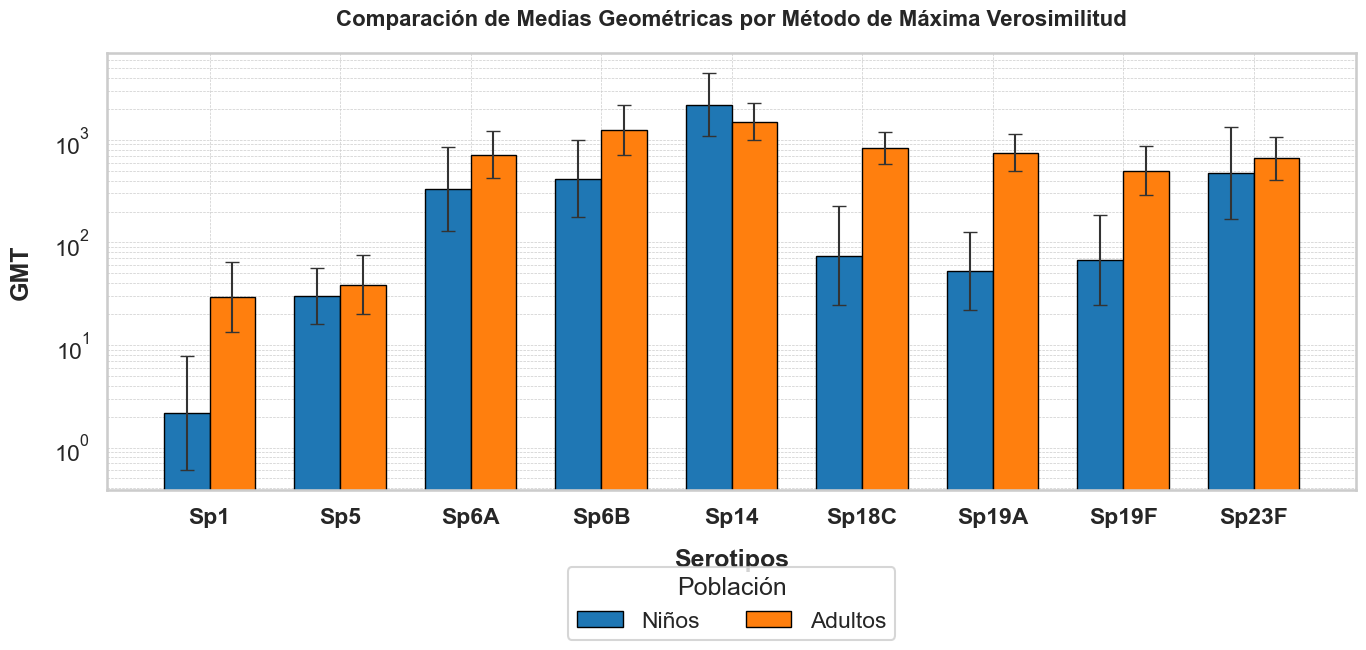

In [47]:
def extraer_limites(columna):
    limpios = columna.str.replace("[", "", regex=False).str.replace(
        "]", "", regex=False
    )
    limites = limpios.str.split(",", expand=True)
    lower = pd.to_numeric(limites[0])
    upper = pd.to_numeric(limites[1])
    return lower, upper

results_mle["GMT_Child_Lower"], results_mle["GMT_Child_Upper"] = (
    extraer_limites(results_mle["CI95_GMT_Ch"])
)
results_mle["GMT_Adult_Lower"], results_mle["GMT_Adult_Upper"] = (
    extraer_limites(results_mle["CI95_GMT_Ad"])
)

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(results_mle["Serotype"]))
width = 0.35

yerr_children = [
    results_mle["GMT_Children"] - results_mle["GMT_Child_Lower"],
    results_mle["GMT_Child_Upper"] - results_mle["GMT_Children"],
]

yerr_adults = [
    results_mle["GMT_Adults"] - results_mle["GMT_Adult_Lower"],
    results_mle["GMT_Adult_Upper"] - results_mle["GMT_Adults"],
]

ax.bar(
    x - width / 2,
    results_mle["GMT_Children"],
    width,
    yerr=yerr_children,
    color="#1f77b4",
    edgecolor="black",
    linewidth=1,
    error_kw={"capsize": 5, "linewidth": 1.5, "ecolor": "#333333"},
    label="Niños",
)

ax.bar(
    x + width / 2,
    results_mle["GMT_Adults"],
    width,
    yerr=yerr_adults,
    color="#ff7f0e",
    edgecolor="black",
    linewidth=1,
    error_kw={"capsize": 5, "linewidth": 1.5, "ecolor": "#333333"},
    label="Adultos",
)

ax.set_yscale("log")
ax.set_title(
    "Comparación de Medias Geométricas por Método de Máxima Verosimilitud",
    fontweight="bold",
    fontsize=16,
    pad=20,
)
ax.set_xlabel("Serotipos", fontweight="bold", labelpad=15)
ax.set_ylabel(
    "GMT", fontweight="bold", labelpad=15
)

ax.set_xticks(x)
ax.set_xticklabels(results_mle["Serotype"], fontweight="bold")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

ax.legend(
    title="Población",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=True,
)

plt.tight_layout()
plt.savefig("gmtm.png", dpi=300, bbox_inches="tight")
plt.show()

## Comparación entre métodos

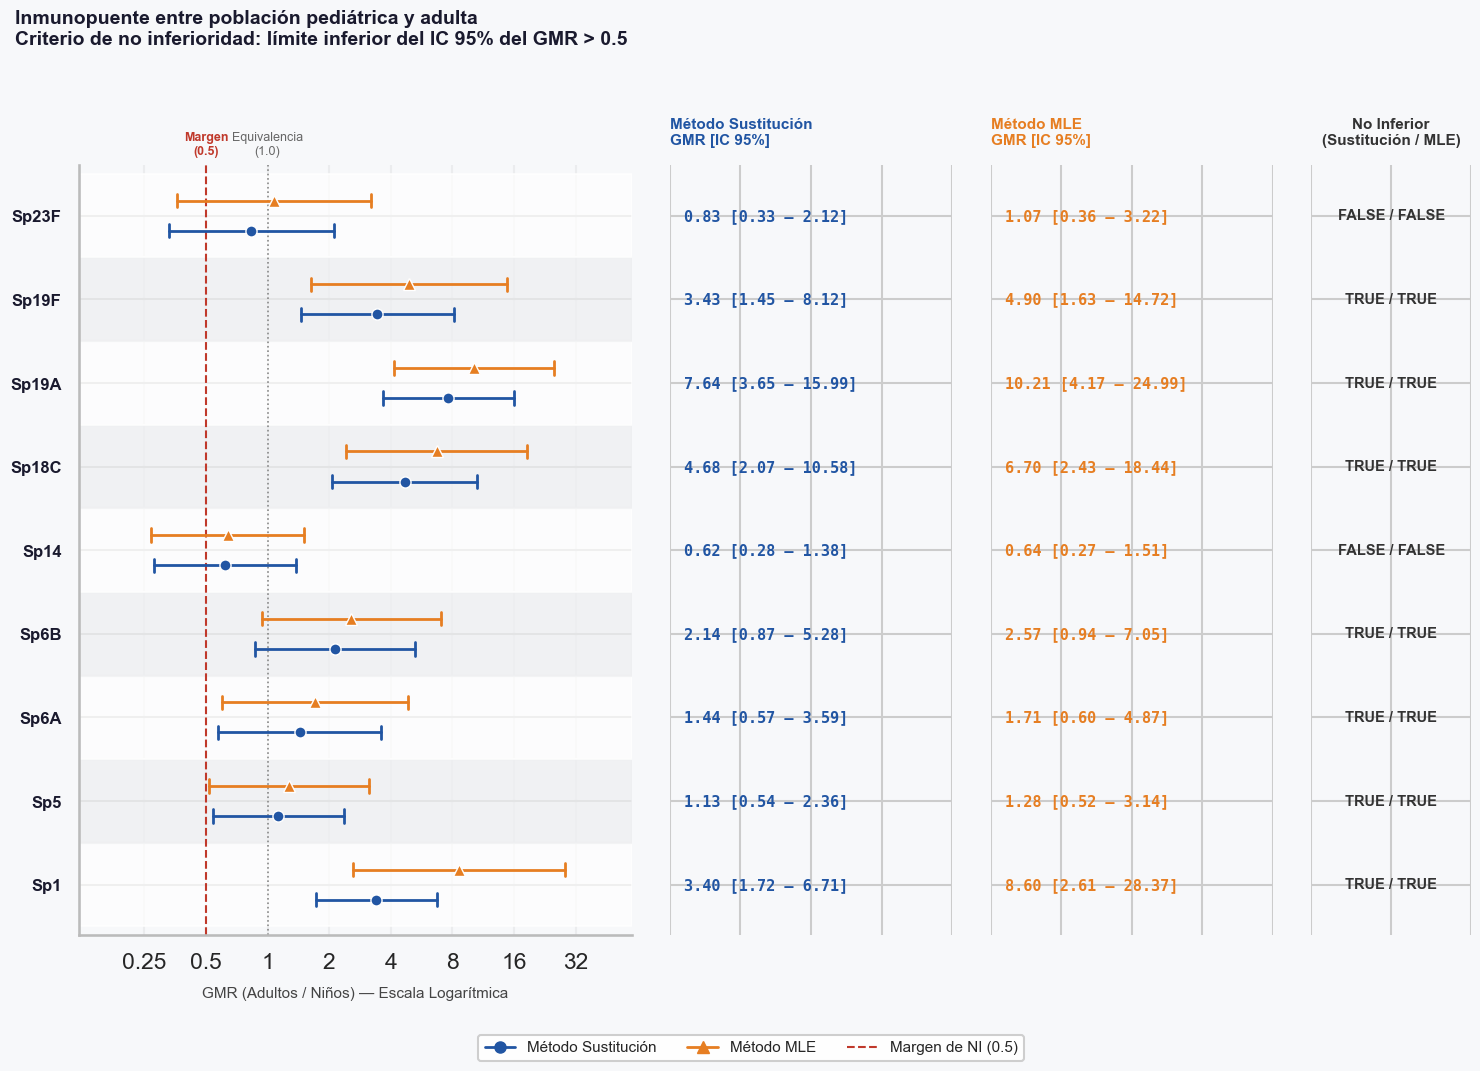

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np


serotypes = ['Sp1', 'Sp5', 'Sp6A', 'Sp6B', 'Sp14', 'Sp18C', 'Sp19A', 'Sp19F', 'Sp23F']
y = np.arange(len(serotypes))

df_imputacion = {
    'GMR': np.array([3.40, 1.13, 1.44, 2.14, 0.62, 4.68, 7.64, 3.43, 0.83]), 
    'CI95_Lower': np.array([1.72, 0.54, 0.57, 0.87, 0.28, 2.07, 3.65, 1.45, 0.33]),
    'CI95_Upper': np.array([6.71, 2.36, 3.59, 5.28, 1.38, 10.58, 15.99, 8.12, 2.12]),
    'Non_Inferior': ['True', 'True', 'True', 'True', 'False', 'True', 'True', 'True', 'False']
}

df_mle = {
    'GMR': np.array([8.60, 1.28, 1.71, 2.57, 0.64, 6.70, 10.21, 4.90, 1.07]),
    'CI95_Lower': np.array([2.61, 0.52, 0.60, 0.94, 0.27, 2.43, 4.17, 1.63, 0.36]),
    'CI95_Upper': np.array([28.37, 3.14, 4.87, 7.05, 1.51, 18.44, 24.99, 14.72, 3.22]),
    'Non_Inferior': ['True', 'True', 'True', 'True', 'False', 'True', 'True', 'True', 'False']
}

COLOR_IMPUT = '#2155A3' 
COLOR_MLE   = '#E67E22'  
COLOR_TEXT  = '#1A1A2E'

plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans']})

fig, axs = plt.subplots(1, 4, figsize=(16, len(serotypes) * 0.85 + 3.5), 
                        sharey=True, gridspec_kw={'width_ratios': [4.5, 2.3, 2.3, 1.3]})
fig.patch.set_facecolor('#F7F8FA')
ax_plot, ax_t1, ax_t2, ax_t3 = axs

for ax in [ax_t1, ax_t2, ax_t3]:
    ax.set_facecolor('#F7F8FA')
    ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False)
    ax.tick_params(left=False, right=False, labelleft=False, labelbottom=False)

ax_plot.set_facecolor('#F7F8FA')

for i in range(len(serotypes)):
    ax_plot.axhspan(i - 0.5, i + 0.5, color='white' if i % 2 == 0 else '#EEEFF1', alpha=0.7, zorder=1)

ax_plot.axvline(0.5, color='#C0392B', linestyle='--', linewidth=1.5, zorder=2)
ax_plot.axvline(1.0, color='#888888', linestyle=':', linewidth=1.2, zorder=2)

offset = 0.18
cap_size = 0.08  

for i in range(len(serotypes)):
    y_imput = i - offset
    ax_plot.plot([df_imputacion['CI95_Lower'][i], df_imputacion['CI95_Upper'][i]], [y_imput, y_imput], 
                color=COLOR_IMPUT, linewidth=2.0, zorder=3)
    ax_plot.plot([df_imputacion['CI95_Lower'][i], df_imputacion['CI95_Lower'][i]], [y_imput - cap_size, y_imput + cap_size], color=COLOR_IMPUT, linewidth=2.0, zorder=3)
    ax_plot.plot([df_imputacion['CI95_Upper'][i], df_imputacion['CI95_Upper'][i]], [y_imput - cap_size, y_imput + cap_size], color=COLOR_IMPUT, linewidth=2.0, zorder=3)
    ax_plot.plot(df_imputacion['GMR'][i], y_imput, 'o', color=COLOR_IMPUT, markersize=8, markeredgecolor='white', zorder=4)
    y_mle = i + offset
    ax_plot.plot([df_mle['CI95_Lower'][i], df_mle['CI95_Upper'][i]], [y_mle, y_mle], 
                color=COLOR_MLE, linewidth=2.0, zorder=3)
    ax_plot.plot([df_mle['CI95_Lower'][i], df_mle['CI95_Lower'][i]], [y_mle - cap_size, y_mle + cap_size], color=COLOR_MLE, linewidth=2.0, zorder=3)
    ax_plot.plot([df_mle['CI95_Upper'][i], df_mle['CI95_Upper'][i]], [y_mle - cap_size, y_mle + cap_size], color=COLOR_MLE, linewidth=2.0, zorder=3)
    ax_plot.plot(df_mle['GMR'][i], y_mle, '^', color=COLOR_MLE, markersize=9, markeredgecolor='white', zorder=4)

ax_plot.set_xscale('log')
ticks = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0]
ax_plot.set_xticks(ticks)
ax_plot.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax_plot.set_xlim(0.12, 60) 

ax_plot.set_yticks(y)
ax_plot.set_yticklabels(serotypes, fontsize=12, fontweight='bold', color=COLOR_TEXT)
ax_plot.set_xlabel('GMR (Adultos / Niños) — Escala Logarítmica', fontsize=11, color='#444444', labelpad=10)
ax_plot.set_ylim(-0.6, len(serotypes) - 0.4)

ax_plot.spines[['top', 'right']].set_visible(False)
ax_plot.spines[['left', 'bottom']].set_color('#BBBBBB')
ax_plot.grid(axis='x', alpha=0.15, color='#AAAAAA')

ax_plot.text(0.5, len(serotypes) - 0.3, 'Margen\n(0.5)', va='bottom', ha='center', fontsize=9, color='#C0392B', fontweight='bold')
ax_plot.text(1.0, len(serotypes) - 0.3, 'Equivalencia\n(1.0)', va='bottom', ha='center', fontsize=9, color='#666666')


for i in range(len(serotypes)):
    txt_imput = f"{df_imputacion['GMR'][i]:.2f} [{df_imputacion['CI95_Lower'][i]:.2f} – {df_imputacion['CI95_Upper'][i]:.2f}]"
    ax_t1.text(0.05, i, txt_imput, va='center', ha='left', fontsize=11, fontfamily='monospace', color=COLOR_IMPUT, fontweight='bold')
    
    txt_mle = f"{df_mle['GMR'][i]:.2f} [{df_mle['CI95_Lower'][i]:.2f} – {df_mle['CI95_Upper'][i]:.2f}]"
    ax_t2.text(0.05, i, txt_mle, va='center', ha='left', fontsize=11, fontfamily='monospace', color=COLOR_MLE, fontweight='bold')
    
    txt_ni = f"{df_imputacion['Non_Inferior'][i].upper()} / {df_mle['Non_Inferior'][i].upper()}"
    ax_t3.text(0.5, i, txt_ni, va='center', ha='center', fontsize=10.5, fontweight='bold', color='#333333')

ax_t1.set_title('Método Sustitución\nGMR [IC 95%]', fontsize=11, fontweight='bold', color=COLOR_IMPUT, pad=15, loc='left')
ax_t2.set_title('Método MLE\nGMR [IC 95%]', fontsize=11, fontweight='bold', color=COLOR_MLE, pad=15, loc='left')
ax_t3.set_title('No Inferior\n(Sustitución / MLE)', fontsize=11, fontweight='bold', color='#333333', pad=15, loc='center')


plt.suptitle('Inmunopuente entre población pediátrica y adulta\n'
             'Criterio de no inferioridad: límite inferior del IC 95% del GMR > 0.5',
             fontsize=14, fontweight='bold', color=COLOR_TEXT, x=0.04, ha='left', y=0.97)

legend_elements = [
    plt.Line2D([0], [0], color=COLOR_IMPUT, marker='o', linestyle='-', linewidth=2, markersize=8, label='Método Sustitución'),
    plt.Line2D([0], [0], color=COLOR_MLE, marker='^', linestyle='-', linewidth=2, markersize=9, label='Método MLE'),
    plt.Line2D([0], [0], color='#C0392B', linestyle='--', linewidth=1.5, label='Margen de NI (0.5)')
]
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.02),
           ncol=3, fontsize=11, framealpha=0.95, edgecolor='#CCCCCC')

plt.subplots_adjust(top=0.83, bottom=0.14, left=0.08, right=0.95, wspace=0.12)

plt.savefig('forest_plot_comparacion.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

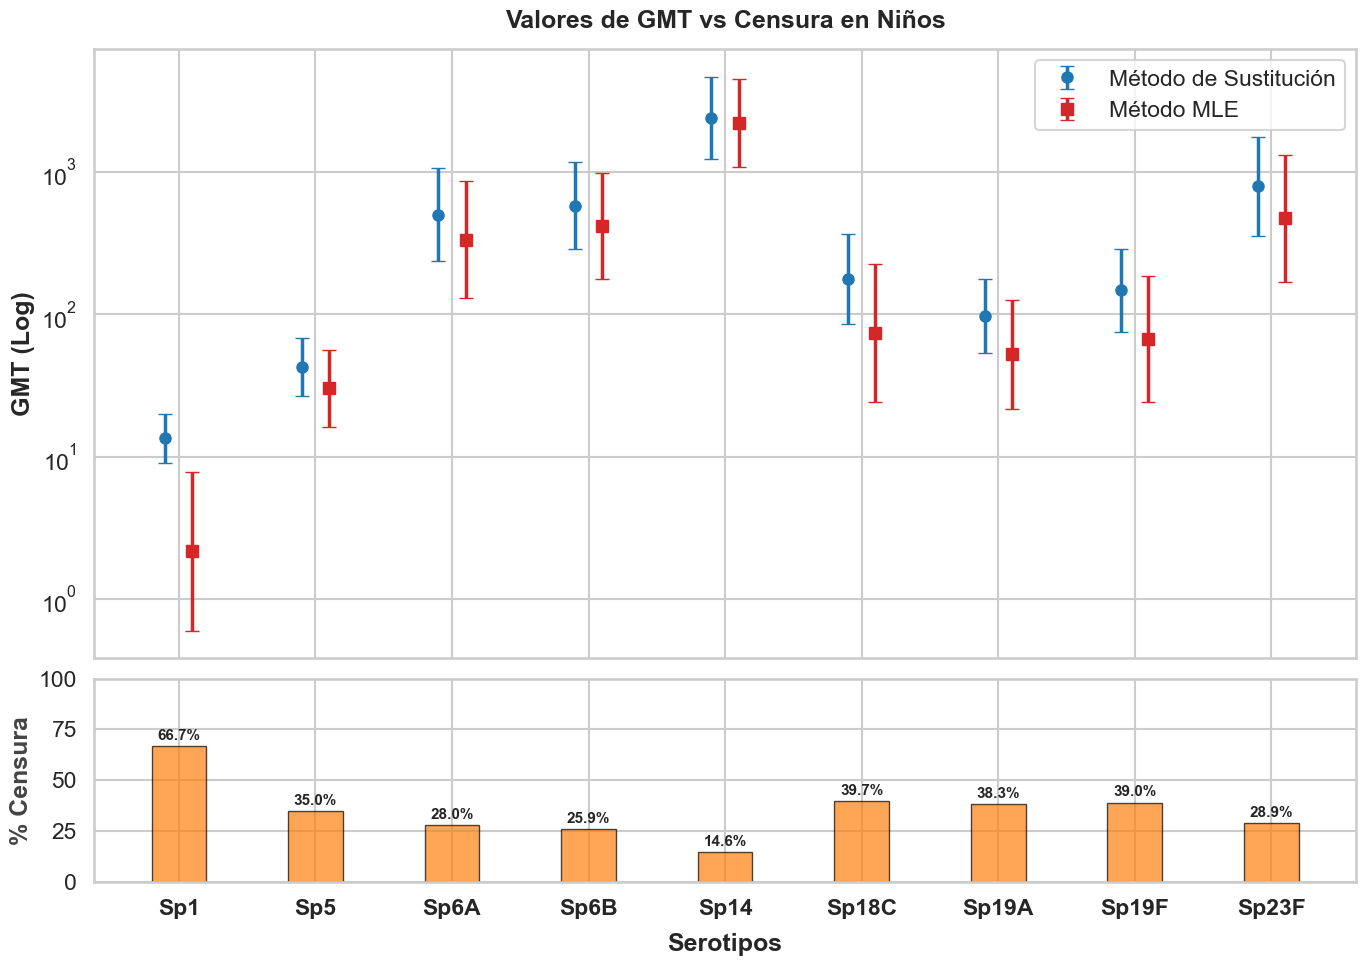

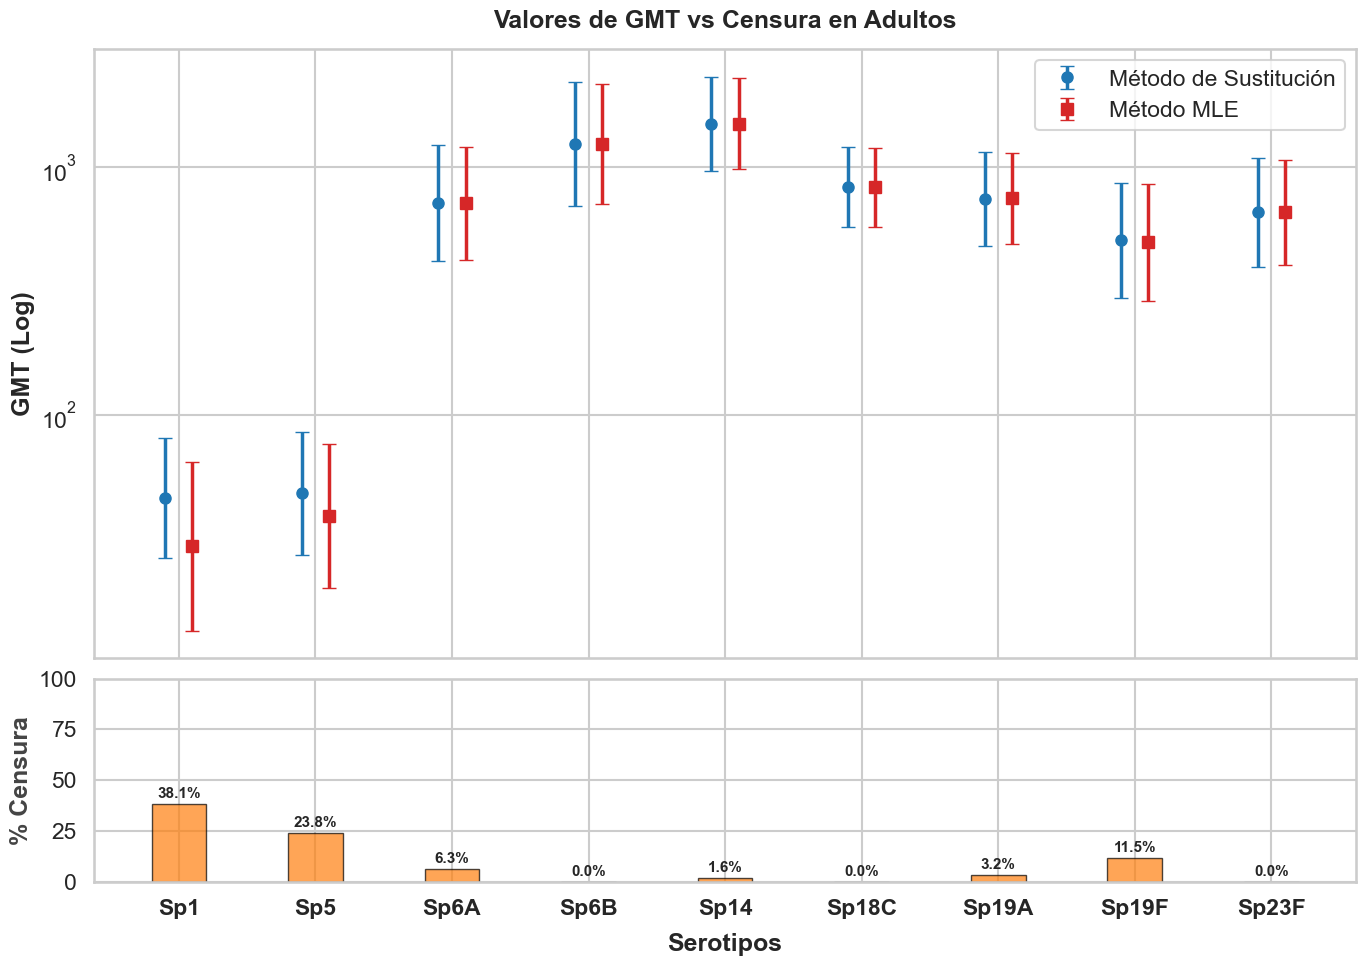

In [53]:
def extraer_limites_mle(columna):
    clean = columna.str.replace("[", "", regex=False).str.replace(
        "]", "", regex=False
    )
    limits = clean.str.split(",", expand=True)
    return pd.to_numeric(limits[0]), pd.to_numeric(limits[1])

for df in [results_mle]:
    df["GMT_Child_Lower"], df["GMT_Child_Upper"] = extraer_limites_mle(
        df["CI95_GMT_Ch"]
    )
    df["GMT_Adult_Lower"], df["GMT_Adult_Upper"] = extraer_limites_mle(
        df["CI95_GMT_Ad"]
    )
    df["Cens_Children_Pct"] = (
        df["Cens_Children"].str.extract(r"\(([\d.]+)%\)").astype(float)
    )
    df["Cens_Adults_Pct"] = (
        df["Cens_Adults"].str.extract(r"\(([\d.]+)%\)").astype(float)
    )

sns.set_theme(style="whitegrid", context="talk")
serotypes = results_df["Serotype"].values
x_pos = np.arange(len(serotypes))
width = 0.2

color_sustitucion = "#1f77b4"
color_mle = "#d62728" 
color_censura = "#ff7f0e"  

fig1, (ax1_top, ax1_bot) = plt.subplots(
    2, 1, figsize=(14, 10), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

err_sust_child = [
    results_df["GMT_Children"] - results_df["GMT_Child_Lower"],
    results_df["GMT_Child_Upper"] - results_df["GMT_Children"],
]
err_mle_child = [
    results_mle["GMT_Children"] - results_mle["GMT_Child_Lower"],
    results_mle["GMT_Child_Upper"] - results_mle["GMT_Children"],
]

ax1_top.errorbar(
    x_pos - width / 2,
    results_df["GMT_Children"],
    yerr=err_sust_child,
    fmt="o",
    color=color_sustitucion,
    markersize=8,
    linewidth=2.5,
    capsize=5,
    label="Método de Sustitución",
)
ax1_top.errorbar(
    x_pos + width / 2,
    results_mle["GMT_Children"],
    yerr=err_mle_child,
    fmt="s",
    color=color_mle,
    markersize=8,
    linewidth=2.5,
    capsize=5,
    label="Método MLE",
)

ax1_top.set_yscale("log")
ax1_top.set_title(
    "Valores de GMT vs Censura en Niños",
    fontweight="bold",
    pad=15,
)
ax1_top.set_ylabel("GMT (Log)", fontweight="bold")
ax1_top.legend(loc="upper right", frameon=True)
ax1_bot.bar(
    x_pos,
    results_mle["Cens_Children_Pct"],
    width=0.4,
    color=color_censura,
    alpha=0.7,
    edgecolor="black",
    linewidth=1,
)
ax1_bot.set_ylabel("% Censura", fontweight="bold", color="#444444")
ax1_bot.set_ylim(0, 100)
ax1_bot.set_xlabel("Serotipos", fontweight="bold", labelpad=10)
ax1_bot.set_xticks(x_pos)
ax1_bot.set_xticklabels(serotypes, fontweight="bold")

for i, val in enumerate(results_mle["Cens_Children_Pct"]):
    ax1_bot.text(
        i, val + 3, f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold"
    )

plt.tight_layout()
fig1.subplots_adjust(hspace=0.05) 
plt.savefig("GMT_vs_Censura_Ninnos.png", dpi=300)
plt.show()

fig2, (ax2_top, ax2_bot) = plt.subplots(
    2, 1, figsize=(14, 10), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
err_sust_adult = [
    results_df["GMT_Adults"] - results_df["GMT_Adult_Lower"],
    results_df["GMT_Adult_Upper"] - results_df["GMT_Adults"],
]
err_mle_adult = [
    results_mle["GMT_Adults"] - results_mle["GMT_Adult_Lower"],
    results_mle["GMT_Adult_Upper"] - results_mle["GMT_Adults"],
]

ax2_top.errorbar(
    x_pos - width / 2,
    results_df["GMT_Adults"],
    yerr=err_sust_adult,
    fmt="o",
    color=color_sustitucion,
    markersize=8,
    linewidth=2.5,
    capsize=5,
    label="Método de Sustitución",
)
ax2_top.errorbar(
    x_pos + width / 2,
    results_mle["GMT_Adults"],
    yerr=err_mle_adult,
    fmt="s",
    color=color_mle,
    markersize=8,
    linewidth=2.5,
    capsize=5,
    label="Método MLE",
)

ax2_top.set_yscale("log")
ax2_top.set_title(
    "Valores de GMT vs Censura en Adultos",
    fontweight="bold",
    pad=15,
)
ax2_top.set_ylabel("GMT (Log)", fontweight="bold")
ax2_top.legend(loc="upper right", frameon=True)
ax2_bot.bar(
    x_pos,
    results_mle["Cens_Adults_Pct"],
    width=0.4,
    color=color_censura,
    alpha=0.7,
    edgecolor="black",
    linewidth=1,
)
ax2_bot.set_ylabel("% Censura", fontweight="bold", color="#444444")
ax2_bot.set_ylim(0, 100)
ax2_bot.set_xlabel("Serotipos", fontweight="bold", labelpad=10)
ax2_bot.set_xticks(x_pos)
ax2_bot.set_xticklabels(serotypes, fontweight="bold")
for i, val in enumerate(results_mle["Cens_Adults_Pct"]):
    ax2_bot.text(
        i, val + 3, f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold"
    )

plt.tight_layout()
fig2.subplots_adjust(hspace=0.05)
plt.savefig("GMT_vs_Censura_Adultos.png", dpi=300)
plt.show()